# Kaggle 50 Startups Dataset：CRISP-DM 學習總整理

本 Notebook 將 `learning.txt` 的原有學習問題重新整理成可以逐格執行的教材，並將較複雜的模型比較與評估內容拆分為 **25 個循序學習問題**。

## 學習目標

- 使用 CRISP-DM 六階段完成一個回歸專案
- 正確區分特徵 `X` 與目標 `y`
- 避免 Data Leakage
- 實作五種特徵篩選方法
- 建立、比較、解讀 Linear Regression 模型
- 建立簡易 Profit 預測函式

> 建議依序執行所有儲存格，並閱讀每題下方的解讀。

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from matplotlib import font_manager
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE, SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RepeatedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

# 設定中文字型。依序尋找 Windows、macOS、Linux 常見中文字型。
CHINESE_FONT_CANDIDATES = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "PingFang TC",
    "Noto Sans CJK TC",
    "Noto Sans TC",
    "Arial Unicode MS",
]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
CHINESE_FONT = next(
    (font for font in CHINESE_FONT_CANDIDATES if font in installed_fonts),
    "DejaVu Sans",
)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [CHINESE_FONT, "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print(f"圖表中文字型：{CHINESE_FONT}")

DATA_PATH = Path("50_Startups.csv")
TARGET = "Profit"
NUMERIC_FEATURES = ["R&D Spend", "Administration", "Marketing Spend"]
CATEGORICAL_FEATURES = ["State"]
RANDOM_STATE = 42

圖表中文字型：Microsoft JhengHei


# 前置觀念：為什麼這是回歸問題？

`Profit` 是連續數值，例如 `192261.83`，模型要預測的是一個金額，而不是「高／中／低」類別，因此這是 **Regression（回歸）** 問題。

若目標改成「是否獲利」，才會是 Classification（分類）問題。

# 學習問題 1：想預測什麼？商業目標是什麼？

- **預測目標：** 新創公司的 `Profit`
- **商業目的：** 根據研發、行政、行銷投入與州別，估計可能獲利
- **應用：** 預算規劃、投資評估、資源配置

模型只能呈現資料中的關聯，不能直接證明因果關係。

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"資料筆數：{len(df)}")
display(df.head())

資料筆數：50


,R&D Spend,Administration,Marketing Spend,State,Profit
0,"165,349.2000","136,897.8000","471,784.1000",New York,"192,261.8300"
1,"162,597.7000","151,377.5900","443,898.5300",California,"191,792.0600"
2,"153,441.5100","101,145.5500","407,934.5400",Florida,"191,050.3900"
3,"144,372.4100","118,671.8500","383,199.6200",New York,"182,901.9900"
4,"142,107.3400","91,391.7700","366,168.4200",Florida,"166,187.9400"


# 學習問題 2：哪些是特徵 X？哪一個是目標 y？

- `X`：R&D Spend、Administration、Marketing Spend、State
- `y`：Profit

In [3]:
X_raw = df.drop(columns=TARGET)
y = df[TARGET]
print("X 欄位：", X_raw.columns.tolist())
print("y 名稱：", y.name)
print("X shape:", X_raw.shape, "| y shape:", y.shape)

X 欄位： ['R&D Spend', 'Administration', 'Marketing Spend', 'State']
y 名稱： Profit
X shape: (50, 4) | y shape: (50,)


# 學習問題 3：數值型與類別型特徵有什麼差異？

Linear Regression 需要數值輸入。`State` 是無大小順序的類別，不能直接編成 1、2、3，否則模型會誤以為州別有數值距離與順序。

正確做法是 **One-Hot Encoding**。`drop="first"` 會保留一個參考類別，避免 dummy variable trap。

In [4]:
encoded_demo = pd.get_dummies(X_raw, columns=["State"], drop_first=True, dtype=int)
display(encoded_demo.head())

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,"165,349.2000","136,897.8000","471,784.1000",0,1
1,"162,597.7000","151,377.5900","443,898.5300",0,0
2,"153,441.5100","101,145.5500","407,934.5400",1,0
3,"144,372.4100","118,671.8500","383,199.6200",0,1
4,"142,107.3400","91,391.7700","366,168.4200",1,0


# 學習問題 4：建模前為什麼要觀察資料？

需要確認欄位型態、缺失值、重複值、分布、離群值，以及特徵和目標的初步關係。若資料品質有問題，模型結果也會失真。

In [5]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
display(quality)
print("重複資料筆數：", df.duplicated().sum())
display(df.describe(include="all").T)

,dtype,missing,unique
R&D Spend,float64,0,49
Administration,float64,0,50
Marketing Spend,float64,0,48
State,object,0,3
Profit,float64,0,50


重複資料筆數： 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
R&D Spend,50.0000,NaN,NaN,NaN,"73,721.6156","45,902.2565",0.0000,"39,936.3700","73,051.0800","101,602.8000","165,349.2000"
Administration,50.0000,NaN,NaN,NaN,"121,344.6396","28,017.8028","51,283.1400","103,730.8750","122,699.7950","144,842.1800","182,645.5600"
Marketing Spend,50.0000,NaN,NaN,NaN,"211,025.0978","122,290.3107",0.0000,"129,300.1325","212,716.2400","299,469.0850","471,784.1000"
State,50,3,New York,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profit,50.0000,NaN,NaN,NaN,"112,012.6392","40,306.1803","14,681.4000","90,138.9025","107,978.1900","139,765.9775","192,261.8300"


# 學習問題 5：初步觀察結果與可能重要的特徵

,Profit
Profit,1.0000
R&D Spend,0.9729
Marketing Spend,0.7478
Administration,0.2007


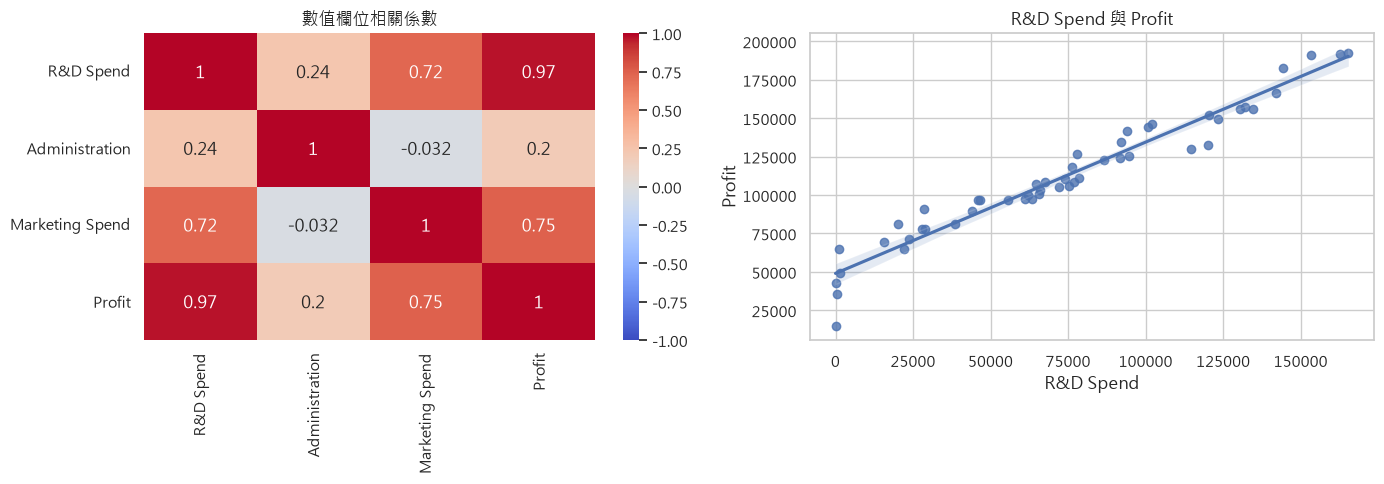

,count,mean,median,std
State,,,,
California,17,"103,905.1753","97,427.8400","44,446.3594"
Florida,16,"118,774.0244","109,543.1200","35,605.4704"
New York,17,"113,756.4465","108,552.0400","41,140.2581"


In [6]:
corr = df.corr(numeric_only=True)
display(corr[[TARGET]].sort_values(TARGET, ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
sns.regplot(data=df, x="R&D Spend", y=TARGET, ax=axes[1])
axes[0].set_title("數值欄位相關係數")
axes[1].set_title("R&D Spend 與 Profit")
plt.tight_layout()
plt.show()

display(df.groupby("State")[TARGET].agg(["count", "mean", "median", "std"]))

**結果解讀：**

- `R&D Spend` 與 `Profit` 的線性關係最強
- `Marketing Spend` 有中度正相關
- `Administration` 的單變量線性關係較弱
- 州別平均獲利不同，但樣本很少，不能直接斷言州別造成獲利差異

# 學習問題 6：為什麼要切分訓練集與測試集？

- Training Set：讓模型學習
- Testing Set：模擬模型面對未見資料的表現

若用同一批資料訓練又評估，分數通常會過度樂觀。

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train_raw.shape, y_train.shape)
print("Test :", X_test_raw.shape, y_test.shape)

Train: (40, 4) (40,)
Test : (10, 4) (10,)


# 學習問題 7：什麼是 Data Leakage？

Data Leakage 是模型訓練時偷看到測試資料資訊。例如先用全部資料做特徵篩選，再切分 Train/Test。

**正確流程：** 先切分資料，再只使用 Training Set 擬合編碼器、標準化器與特徵篩選器。

# 學習問題 8：完整的標準資料準備流程

Data Preparation 不只是 One-Hot Encoding。完整流程必須把原始資料轉換成「模型可以安全學習、測試與部署」的格式。

## 完整流程總覽

1. **確認問題與資料契約**
   - 確認目標欄位是 `Profit`
   - 確認必要輸入欄位、資料型態與合理範圍
   - 避免把目標或目標衍生欄位放入特徵
2. **進行資料品質檢查**
   - 檢查缺失值、重複值、錯誤型態、非法類別與異常值
   - 決定清理規則，但不可因看到測試結果而修改規則
3. **區分特徵 X 與目標 y**
   - `X` 只包含預測時可以取得的資料
   - `y` 是模型需要預測的 `Profit`
4. **先切分 Training Set 與 Testing Set**
   - 所有會從資料學習參數的轉換，都只能在 Training Set 上 `fit`
   - Testing Set 只能使用已學好的轉換器 `transform`
5. **處理缺失值**
   - 數值欄位可使用 Training Set 的中位數填補
   - 類別欄位可使用 Training Set 的眾數填補
   - 本資料目前沒有缺失值，但正式流程仍應準備處理策略
6. **處理類別特徵**
   - `State` 使用 One-Hot Encoding
   - `handle_unknown="ignore"` 可處理測試或部署時出現未見類別
7. **判斷是否需要數值縮放**
   - 一般 Linear Regression 不一定需要縮放
   - Lasso、Ridge、距離模型等對尺度敏感，通常需要 StandardScaler
8. **確認 Train/Test 欄位完全一致**
   - 欄位名稱、順序與數量必須相同
9. **特徵篩選只能使用 Training Set**
   - 測試集不能參與相關係數、p-value、SelectKBest、RFE 或 Lasso 篩選
10. **使用 Pipeline 保存完整轉換流程**
    - 訓練、測試與部署都使用相同處理步驟
    - 降低資料外洩與人工處理錯誤

## 步驟 1：驗證資料契約與品質

這一步先確認必要欄位存在、資料型態正確，以及目標欄位沒有缺失。  
若發現缺失值或異常值，應先定義處理原則；不要看到測試分數後才決定如何清理。

In [8]:
EXPECTED_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]

assert set(df.columns) == set(EXPECTED_COLUMNS), "資料欄位與預期不一致"
assert df[TARGET].notna().all(), "目標欄位 Profit 不可缺失"
assert all(pd.api.types.is_numeric_dtype(df[column]) for column in NUMERIC_FEATURES + [TARGET])

preparation_audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "unique_count": df.nunique(),
})
display(preparation_audit)
print("重複資料筆數：", int(df.duplicated().sum()))
print("State 合法類別：", sorted(df["State"].dropna().unique()))

,dtype,missing_count,unique_count
R&D Spend,float64,0,49
Administration,float64,0,50
Marketing Spend,float64,0,48
State,object,0,3
Profit,float64,0,50


重複資料筆數： 0
State 合法類別： ['California', 'Florida', 'New York']


## 步驟 2：先切分，再學習資料轉換參數

前面已完成 `X_train_raw`、`X_test_raw`、`y_train`、`y_test` 的切分。  
以下所有 `fit` 操作都只能使用 `X_train_raw` 或 `y_train`：

- 缺失值填補值
- One-Hot Encoder 類別集合
- StandardScaler 平均值與標準差
- 特徵篩選規則

測試資料只能呼叫 `transform`，不能重新 `fit`。

## 步驟 3：缺失值策略

這份資料目前沒有缺失值，因此下方手動流程可以直接編碼。正式專案仍建議預先定義：

| 欄位類型 | 建議策略 | 為什麼只用 Training Set？ |
|---|---|---|
| 數值欄位 | 中位數 `median` | 避免測試集分布資訊洩漏 |
| 類別欄位 | 眾數 `most_frequent` | 避免偷看測試集最常見類別 |
| 目標 Profit | 通常刪除該筆或回查來源 | 目標不可任意填補後拿來訓練 |

如果缺失值本身具有商業意義，也可以增加「是否缺失」指標欄位。

## 步驟 4：手動展示 One-Hot Encoding

為了讓後續五種特徵篩選方法可以直接操作欄位名稱，這裡先手動建立 DataFrame。  
關鍵是 Encoder 只在 Training Set 使用 `fit_transform`，Testing Set 只能使用 `transform`。

In [9]:
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
train_state = encoder.fit_transform(X_train_raw[CATEGORICAL_FEATURES])
test_state = encoder.transform(X_test_raw[CATEGORICAL_FEATURES])
state_names = encoder.get_feature_names_out(CATEGORICAL_FEATURES)

X_train = pd.concat([
    X_train_raw[NUMERIC_FEATURES].reset_index(drop=True),
    pd.DataFrame(train_state, columns=state_names),
], axis=1)
X_test = pd.concat([
    X_test_raw[NUMERIC_FEATURES].reset_index(drop=True),
    pd.DataFrame(test_state, columns=state_names),
], axis=1)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("編碼後特徵：", X_train.columns.tolist())
display(X_train.head())

編碼後特徵： ['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']


,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,"93,863.7500","127,320.3800","249,839.4400",1.0000,0.0000
1,"142,107.3400","91,391.7700","366,168.4200",1.0000,0.0000
2,"44,069.9500","51,283.1400","197,029.4200",0.0000,0.0000
3,"120,542.5200","148,718.9500","311,613.2900",0.0000,1.0000
4,"144,372.4100","118,671.8500","383,199.6200",0.0000,1.0000


In [10]:
# 驗證 Train/Test 轉換後結構完全一致
assert X_train.columns.tolist() == X_test.columns.tolist()
assert X_train.shape[1] == X_test.shape[1]
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Train/Test 欄位一致：", X_train.columns.equals(X_test.columns))
display(pd.DataFrame({
    "資料集": ["X_train", "X_test", "y_train", "y_test"],
    "資料筆數": [len(X_train), len(X_test), len(y_train), len(y_test)],
}))

X_train shape: (40, 5)
X_test shape : (10, 5)
Train/Test 欄位一致： True


,資料集,資料筆數
0,X_train,40
1,X_test,10
2,y_train,40
3,y_test,10


## 步驟 5：何時需要 StandardScaler？

- **一般 Linear Regression：** 不縮放仍可得到相同預測能力，原始單位係數也較容易解釋。
- **Lasso-based Selection：** 必須先縮放，否則金額範圍較大的欄位會受到不公平影響。
- **重要原則：** Scaler 只能在 Training Set `fit`，再對 Test Set `transform`。

本 Notebook 會保留未縮放的 `X_train`、`X_test` 建立一般 Linear Regression；到 Lasso 學習問題時才另外使用 StandardScaler。

## 步驟 6：正式專案建議使用 Pipeline

手動流程適合學習每一步；正式訓練與部署則建議使用 `ColumnTransformer + Pipeline`：

- 數值欄位：中位數填補
- 類別欄位：眾數填補後 One-Hot Encoding
- 模型：Linear Regression

Pipeline 在 `.fit()` 時只從 Training Set 學習所有參數，`.predict()` 時會自動套用完全相同的轉換。

In [11]:
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, NUMERIC_FEATURES),
        ("categorical", categorical_preprocessor, CATEGORICAL_FEATURES),
    ],
    verbose_feature_names_out=False,
)

full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

full_pipeline.fit(X_train_raw, y_train)

print("Pipeline 轉換後特徵：", preprocessor.get_feature_names_out().tolist())
print("Pipeline 已只使用 Training Set 完成擬合；外部 Test Set 保留到最後評估。")

Pipeline 轉換後特徵： ['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']
Pipeline 已只使用 Training Set 完成擬合；外部 Test Set 保留到最後評估。


## 資料準備完成後的檢查清單

- [x] 目標 `Profit` 沒有出現在特徵中
- [x] 先切分 Train/Test，才擬合資料轉換器
- [x] 缺失值處理策略已定義
- [x] `State` 已安全完成 One-Hot Encoding
- [x] 未知州別可由 `handle_unknown="ignore"` 處理
- [x] Train/Test 轉換後欄位名稱與順序一致
- [x] 特徵篩選將只使用 Training Set
- [x] 正式部署可使用 Pipeline 重現相同轉換

完成這些檢查後，才進入下一階段的特徵篩選與建模。

# 學習問題 9：什麼是特徵篩選？

特徵篩選會保留較有用的欄位，可能帶來：

- 更簡潔且容易解釋的模型
- 減少雜訊與過度配適風險
- 降低不必要的資料蒐集成本

但特徵越少不一定越好，必須用測試集與交叉驗證比較。

# 學習問題 10：相關係數法

In [12]:
train_corr = X_train.apply(lambda column: column.corr(y_train)).sort_values(
    key=lambda values: values.abs(), ascending=False
)
corr_features = train_corr[train_corr.abs() >= 0.5].index.tolist()
display(train_corr.to_frame("與 Profit 的相關係數"))
print("選取特徵：", corr_features)

,與 Profit 的相關係數
R&D Spend,0.9730
Marketing Spend,0.7738
State_New York,0.1050
State_Florida,0.0955
Administration,0.0902


選取特徵： ['R&D Spend', 'Marketing Spend']


相關係數法快速且容易解釋，但只看每個特徵和目標的單獨線性關係，沒有考慮特徵彼此的互動與共線性。

# 學習問題 11：SelectKBest / f_regression

## 方法核心概念

`SelectKBest` 是一種 **Filter Method（過濾式特徵篩選）**。它不先建立完整的最終模型，而是分別計算每個特徵與目標 `Profit` 的統計關係，再選出分數最高的前 `K` 個特徵。

這裡使用的評分函式是 `f_regression`。對每個特徵，它會執行一個單變量線性迴歸檢定：

- **虛無假設 H₀：** 此特徵與 `Profit` 沒有線性關係，斜率為 0。
- **對立假設 H₁：** 此特徵與 `Profit` 存在線性關係，斜率不為 0。

## F-score 與 p-value 如何判讀？

- **F-score 越大：** 該特徵單獨解釋 `Profit` 的線性能力越強。
- **p-value 越小：** 若實際沒有線性關係，卻觀察到目前 F-score 的機率越低。
- `SelectKBest` 實際依照 **F-score 排名**，不會自動使用 p-value 門檻。

對單一特徵而言，F-score 和 Pearson 相關係數高度相關，因此結果可能與相關係數法相近。但兩者的選取規則不同：

| 方法 | 選取規則 |
|---|---|
| Correlation Threshold | 保留絕對相關係數超過門檻的特徵，特徵數不固定 |
| SelectKBest | 固定選擇 F-score 最高的前 K 個特徵 |

## 執行流程

1. 只使用 Training Set。
2. 分別計算每個特徵對 `Profit` 的 F-score。
3. 將特徵依 F-score 由大到小排序。
4. 保留前 `K` 個特徵。

本例設定 `k=3`，代表無論第三名分數高低，都會選取三個特徵。

In [13]:
kbest = SelectKBest(score_func=f_regression, k=3)
kbest.fit(X_train, y_train)
kbest_features = X_train.columns[kbest.get_support()].tolist()
kbest_table = pd.DataFrame({
    "feature": X_train.columns,
    "F score": kbest.scores_,
    "p-value": kbest.pvalues_,
    "selected": kbest.get_support(),
}).sort_values("F score", ascending=False)
display(kbest_table)
print("選取特徵：", kbest_features)

,feature,F score,p-value,selected
0,R&D Spend,676.1035,0.0000,True
2,Marketing Spend,56.6907,0.0000,True
4,State_New York,0.4238,0.5189,True
3,State_Florida,0.3497,0.5578,False
1,Administration,0.3120,0.5798,False


選取特徵： ['R&D Spend', 'Marketing Spend', 'State_New York']


## 如何解讀本資料集結果？

請先查看上表的 `F score`、`p-value` 與 `selected`：

- `selected=True` 表示該特徵位於前三名。
- 第一名通常是 `R&D Spend`，表示它單獨與 `Profit` 的線性關係最強。
- One-Hot Encoding 後的州別欄位，也會被當成獨立特徵分別評分。

## 優點

- 計算快速，適合特徵很多的資料。
- 結果容易排序與解釋。
- 不依賴最終模型，因此可先快速縮小特徵範圍。

## 限制與注意事項

- 每個特徵都是單獨評分，**不考慮特徵彼此的交互作用與共線性**。
- `k` 必須事先指定；若要調整 K，應在 Training Set 內使用交叉驗證。
- F-test 假設關係主要是線性的，非線性但重要的特徵可能被低估。
- 必須先切分 Train/Test，再於 Training Set 執行 `fit`，否則會造成資料外洩。

# 學習問題 12：Backward Elimination

## 方法核心概念

Backward Elimination 是一種 **Wrapper / Statistical Method**。它從全部候選特徵開始建立多元線性迴歸，然後逐步刪除在「其他特徵已經存在」的條件下，統計上最不顯著的特徵。

它回答的問題不是：

> 這個特徵單獨與 Profit 有沒有關係？

而是：

> 控制模型中其他特徵後，這個特徵是否仍提供額外的線性解釋能力？

## p-value 的假設檢定

對模型中的每個係數，檢定：

- **H₀：** 該特徵係數等於 0；控制其他特徵後，它沒有額外貢獻。
- **H₁：** 該特徵係數不等於 0。

常見門檻為 `0.05`：

- `p-value <= 0.05`：保留，因為有較強證據認為係數不為 0。
- `p-value > 0.05`：可能移除；其中 p-value 最大者優先移除。

## 執行流程

1. 使用所有特徵建立 OLS 模型。
2. 找出 p-value 最大的特徵。
3. 若最大 p-value 大於 `0.05`，移除該特徵。
4. 使用剩餘特徵重新建立模型。
5. 重複執行，直到所有保留特徵的 p-value 都不超過門檻。

每次移除後都必須重新訓練，因為特徵之間可能共享解釋能力。

In [14]:
backward_features = X_train.columns.tolist()
backward_history = []
backward_step = 1

while backward_features:
    ols = sm.OLS(
        y_train,
        sm.add_constant(X_train[backward_features], has_constant="add"),
    ).fit()
    pvalues = ols.pvalues.drop("const")
    worst_feature = pvalues.idxmax()
    worst_pvalue = pvalues.max()
    if worst_pvalue <= 0.05:
        break
    backward_history.append({
        "step": backward_step,
        "removed_feature": worst_feature,
        "p_value_when_removed": worst_pvalue,
        "features_before_removal": ", ".join(backward_features),
        "adjusted_R2_before_removal": ols.rsquared_adj,
    })
    backward_features.remove(worst_feature)
    backward_step += 1

backward_history_df = pd.DataFrame(backward_history)
display(backward_history_df)
print("選取特徵：", backward_features)
print("最終模型 Adjusted R²：", ols.rsquared_adj)
display(ols.summary2().tables[1].rename(columns={"P>|t|": "p-value"}))

,step,removed_feature,p_value_when_removed,features_before_removal,adjusted_R2_before_removal
0,1,State_New York,0.9986,"R&D Spend, Administration, Marketing Spend, St...",0.9469
1,2,State_Florida,0.7755,"R&D Spend, Administration, Marketing Spend, St...",0.9484
2,3,Administration,0.2570,"R&D Spend, Administration, Marketing Spend",0.9497
3,4,Marketing Spend,0.0552,"R&D Spend, Marketing Spend",0.9493


選取特徵： ['R&D Spend']
最終模型 Adjusted R²： 0.9453860654564774


,Coef.,Std.Err.,t,p-value,[0.025,0.975]
const,"49,336.6680","2,985.8187",16.5237,0.0000,"43,292.1940","55,381.1421"
R&D Spend,0.8536,0.0328,26.0020,0.0000,0.7872,0.9201


## 如何解讀本資料集結果？

- `backward_history_df` 顯示每一步移除哪個特徵、當時的 p-value，以及移除前模型的 Adjusted R²。
- 最終係數表中的 `p-value` 顯示保留特徵在最終模型中的顯著性。
- 若最後只保留 `R&D Spend`，代表在目前 Training Set 與 `0.05` 門檻下，其他特徵沒有提供足夠明確的額外線性解釋能力。

這不代表被移除特徵在商業上完全不重要，也不代表它們沒有因果效果。

## 優點

- 同時考慮多個特徵，能觀察控制其他變數後的額外貢獻。
- 最終模型通常較簡潔，並有清楚的 p-value 解釋。
- 適合希望進行統計推論與模型解釋的情境。

## 限制與注意事項

- p-value 會受到樣本量、離群值、共線性與線性迴歸假設影響。
- 小型資料集的選取結果可能不穩定；換一次 Train/Test Split 可能得到不同結果。
- 逐步選擇後的 p-value 會有選模偏誤，不應視為完全獨立的正式推論。
- 門檻 `0.05` 是慣例，不是永遠正確的答案。
- 所有步驟只能在 Training Set 執行。

# 學習問題 13：Recursive Feature Elimination（RFE）

## 方法核心概念

RFE 是一種 **Wrapper Method（包裝式方法）**。它使用指定的模型反覆訓練，依模型提供的特徵重要性刪除較弱的特徵，直到剩下指定數量。

搭配 `LinearRegression` 時，RFE 使用迴歸係數絕對值判斷特徵重要性：

- 係數絕對值較大：模型認為影響較強。
- 係數絕對值較小：較早被移除。

## 為什麼 RFE 前需要注意尺度？

`R&D Spend` 等金額特徵的數值可能是數十萬，而州別 dummy 只有 0 或 1。直接比較原始係數大小可能不公平，因此本例先使用 Training Set 的 `StandardScaler` 標準化，再執行 RFE。

最終 Linear Regression 仍可使用原始尺度資料重新訓練，以保留容易解讀的原始單位係數。

## 執行流程

1. 指定基礎模型，例如 `LinearRegression`。
2. 使用全部特徵訓練模型。
3. 根據係數重要性移除最弱特徵。
4. 使用剩餘特徵重新訓練。
5. 重複直到剩下 `n_features_to_select` 個特徵。

本例指定保留 3 個特徵，`step=1` 表示每輪移除 1 個。

In [15]:
X_train_rfe_scaled = StandardScaler().fit_transform(X_train)
rfe = RFE(LinearRegression(), n_features_to_select=3, step=1)
rfe.fit(X_train_rfe_scaled, y_train)
rfe_features = X_train.columns[rfe.support_].tolist()
all_feature_scaled_model = LinearRegression().fit(X_train_rfe_scaled, y_train)
rfe_table = pd.DataFrame({
    "feature": X_train.columns,
    "selected": rfe.support_,
    "ranking": rfe.ranking_,
    "initial_standardized_coefficient": all_feature_scaled_model.coef_,
    "absolute_initial_coefficient": np.abs(all_feature_scaled_model.coef_),
}).sort_values(["ranking", "absolute_initial_coefficient"], ascending=[True, False])
display(rfe_table)
print("選取特徵：", rfe_features)

,feature,selected,ranking,initial_standardized_coefficient,absolute_initial_coefficient
0,R&D Spend,True,1,"38,102.2693","38,102.2693"
2,Marketing Spend,True,1,"3,386.1758","3,386.1758"
1,Administration,True,1,"-1,864.7543","1,864.7543"
3,State_Florida,False,2,447.7757,447.7757
4,State_New York,False,3,3.2729,3.2729


選取特徵： ['R&D Spend', 'Administration', 'Marketing Spend']


## 如何解讀本資料集結果？

- `selected=True` 或 `ranking=1` 表示最後保留的特徵。
- `ranking=2` 表示最後一輪前被移除；排名數字越大，越早被移除。
- `initial_standardized_coefficient` 是第一輪全部特徵模型的標準化係數，只用來輔助理解；RFE 每輪都會重新訓練，所以最終排名不只由第一輪決定。

## 優點

- 會考慮基礎模型中的多特徵關係。
- 可直接控制希望保留的特徵數量。
- 比單變量 Filter Method 更貼近最終模型行為。

## 限制與注意事項

- 必須事先指定保留幾個特徵。
- 結果依賴基礎模型；換成其他模型可能得到不同特徵。
- 特徵尺度會影響線性模型係數，因此需先標準化後再比較。
- 特徵數很多時，反覆訓練的計算成本較高。
- `n_features_to_select` 應在 Training Set 內透過交叉驗證決定，不能依測試集結果反覆修改。

# 學習問題 14：Lasso-based Selection

## 方法核心概念

Lasso 是一種 **Embedded Method（嵌入式方法）**：在訓練迴歸模型的同時完成特徵篩選。

一般線性迴歸最小化預測平方誤差；Lasso 額外加入 L1 懲罰：

`目標函數 = 預測平方誤差 + alpha × 所有係數絕對值總和`

L1 懲罰會鼓勵模型把部分係數精確壓縮為 0：

- 係數不為 0：保留特徵。
- 係數為 0：移除特徵。

## alpha 控制什麼？

- `alpha` 越小：懲罰較弱，保留較多特徵，接近一般 Linear Regression。
- `alpha` 越大：懲罰較強，更多係數變成 0，模型更簡潔。
- `LassoCV` 使用交叉驗證，在 Training Set 中尋找合適的 alpha。

## 為什麼一定要先標準化？

Lasso 直接懲罰係數大小。若特徵尺度不同，係數大小不可公平比較，因此必須先使用 Training Set 的 `StandardScaler`。

## 執行流程

1. 在 Training Set 擬合 StandardScaler。
2. 將 Training Set 標準化。
3. 使用五折交叉驗證評估多個 alpha。
4. 選擇交叉驗證誤差較低的 alpha。
5. 保留係數不為 0 的特徵。
6. 使用選出的特徵重新建立可解釋的 Linear Regression。

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=100_000)
lasso.fit(X_train_scaled, y_train)
lasso_coef = pd.Series(lasso.coef_, index=X_train.columns)
lasso_features = lasso_coef[lasso_coef.abs() > 1e-8].index.tolist()
lasso_table = pd.DataFrame({
    "feature": X_train.columns,
    "standardized_coefficient": lasso_coef,
    "absolute_coefficient": lasso_coef.abs(),
    "selected": lasso_coef.abs() > 1e-8,
}).sort_values("absolute_coefficient", ascending=False)
display(lasso_table)
print("最佳 alpha：", lasso.alpha_)
print("選取特徵：", lasso_features)

,feature,standardized_coefficient,absolute_coefficient,selected
R&D Spend,R&D Spend,"36,546.5638","36,546.5638",True
Marketing Spend,Marketing Spend,"3,554.8005","3,554.8005",True
Administration,Administration,-378.0947,378.0947,True
State_Florida,State_Florida,0.0000,0.0000,False
State_New York,State_New York,-0.0000,0.0000,False


最佳 alpha： 1232.8853794684767
選取特徵： ['R&D Spend', 'Administration', 'Marketing Spend']


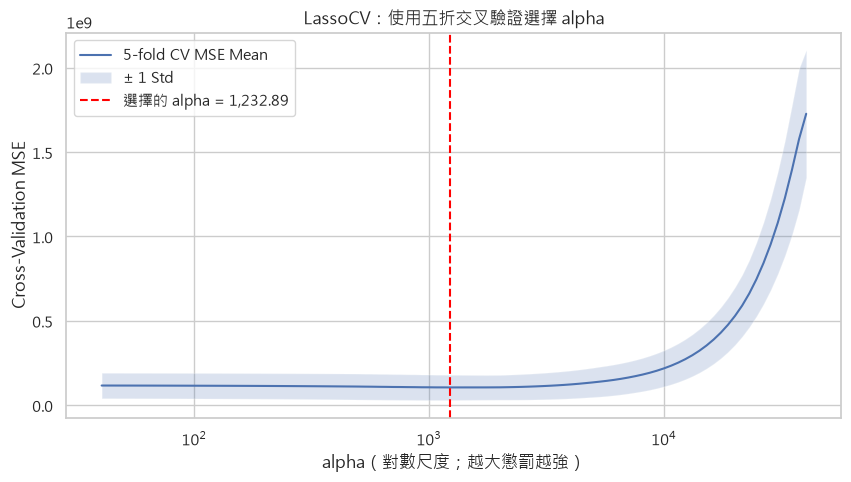

In [17]:
# 顯示 LassoCV 如何利用不同 alpha 的五折交叉驗證誤差選擇 alpha
lasso_cv_mse_mean = lasso.mse_path_.mean(axis=1)
lasso_cv_mse_std = lasso.mse_path_.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(lasso.alphas_, lasso_cv_mse_mean, label="5-fold CV MSE Mean")
plt.fill_between(
    lasso.alphas_,
    lasso_cv_mse_mean - lasso_cv_mse_std,
    lasso_cv_mse_mean + lasso_cv_mse_std,
    alpha=0.2,
    label="± 1 Std",
)
plt.axvline(lasso.alpha_, color="red", linestyle="--", label=f"選擇的 alpha = {lasso.alpha_:,.2f}")
plt.xscale("log")
plt.xlabel("alpha（對數尺度；越大懲罰越強）")
plt.ylabel("Cross-Validation MSE")
plt.title("LassoCV：使用五折交叉驗證選擇 alpha")
plt.legend()
plt.show()

## 如何解讀本資料集結果？

- `standardized_coefficient` 是標準化尺度下的係數，可比較相對影響方向與強度。
- `selected=True` 表示係數未被壓縮為 0。
- alpha 圖中的紅色虛線表示 `LassoCV` 最終選擇的懲罰強度。
- 若某特徵係數為 0，表示在目前 alpha 與其他特徵存在時，Lasso 認為可以不保留它。

## 優點

- 同時完成模型訓練、正則化與特徵篩選。
- 可降低過度配適風險。
- 適合特徵較多、希望得到稀疏模型的情境。

## 限制與注意事項

- 必須正確標準化特徵。
- 高度相關的特徵可能互相競爭，Lasso 可能只保留其中一個，選擇結果可能不穩定。
- alpha 與交叉驗證切分會影響保留特徵。
- Lasso 篩選使用標準化係數；最終商業解讀通常應以選取特徵重新建立原始尺度 Linear Regression。
- Scaler 與 LassoCV 都只能使用 Training Set 擬合。

# 學習問題 15：整理五種特徵篩選結果

In [18]:
selection_summary = pd.DataFrame({
    "方法": ["Correlation", "SelectKBest", "Backward Elimination", "RFE", "Lasso"],
    "選取特徵": [
        ", ".join(corr_features),
        ", ".join(kbest_features),
        ", ".join(backward_features),
        ", ".join(rfe_features),
        ", ".join(lasso_features),
    ],
    "特徵數": [
        len(corr_features), len(kbest_features), len(backward_features),
        len(rfe_features), len(lasso_features),
    ],
})
display(selection_summary)

,方法,選取特徵,特徵數
0,Correlation,"R&D Spend, Marketing Spend",2
1,SelectKBest,"R&D Spend, Marketing Spend, State_New York",3
2,Backward Elimination,R&D Spend,1
3,RFE,"R&D Spend, Administration, Marketing Spend",3
4,Lasso,"R&D Spend, Administration, Marketing Spend",3


## 為什麼 RFE 與 Lasso 可能選到相同特徵？

RFE 與 Lasso 的原理不同，但選到相同特徵並不奇怪：

- **RFE** 反覆訓練 Linear Regression，逐步移除影響較小的特徵。
- **Lasso** 透過 L1 懲罰壓縮係數；本 Notebook 的固定 `k` 比較會依標準化後 Lasso 係數絕對值挑選前 `k` 名。
- 兩者都以線性模型與係數強度判斷特徵，而且都先處理尺度問題。
- 本資料中 `R&D Spend` 與 Profit 的線性關係非常強，`Marketing Spend` 通常次之，因此不同方法容易先選到相同特徵。

若兩種方法在同一折選到完全相同的特徵集合，後續又使用相同的 Linear Regression，它們的 Validation 預測與 RMSE 必然相同。這不是程式錯誤，而是兩條不同的選擇路徑最後建立了同一個模型。

不過，使用完整 Training Set 得到相同特徵，不代表每個 CV Fold 都會相同。下方 Pipeline + CV 明細會顯示各方法在每個 `k`、每一折實際挑選的特徵。

## Correlation 方法的定位與限制

Correlation 是簡單的 **Filter Method**，會分別衡量每個特徵與 Profit 的線性關係。它速度快、容易解釋，適合作為初步探索與 Baseline，但通常不應單獨作為最終特徵選擇依據，原因包括：

- 只看每個特徵與目標的單變量關係，忽略其他特徵同時存在時的條件效果。
- 無法充分處理特徵間共線性、互補效果與交互作用。
- Correlation 門檻具有主觀性，門檻改變可能造成特徵集合改變。

本資料中 `R&D Spend` 對 Profit 的線性關係非常強，因此 Correlation 選出的簡單模型仍可得到不錯分數。這代表資料結構較簡單，不代表 Correlation 是整體上最好的特徵選擇方法。

# 補充學習問題：要固定特徵數，還是讓方法自行決定？

## 為什麼這個問題重要？

不同特徵篩選方法的設計目標不同：

- Correlation、SelectKBest、RFE 很容易指定固定特徵數。
- Backward Elimination 通常使用 p-value 門檻決定停止時機。
- Lasso 通常使用交叉驗證選擇懲罰強度，再保留非零係數。

如果各方法最後使用的特徵數不同，模型表現差異可能同時來自「篩選方法」與「特徵數量」。

## 建議採用兩階段比較

### 第一階段：固定特徵數，公平比較篩選方法

所有方法都選擇相同數量，例如固定選擇 2 個特徵。此階段主要回答：

> 在相同模型複雜度下，哪一種方法選出的特徵較有效？

### 第二階段：讓各方法依自己的規則決定特徵數

此階段主要回答：

> 實際建立模型時，哪個方法與特徵組合具有最佳泛化能力？

本 Notebook 的正式模型選擇使用第二階段，並加入 Full Feature Baseline；下方先執行第一階段的固定特徵數比較。

避免用測試集反覆調整特徵數，否則測試集也會被洩漏。

In [19]:
# 固定所有方法選擇 2 個特徵，只使用 Training Set 決定特徵
FIXED_K = 2

fixed_corr = train_corr.abs().nlargest(FIXED_K).index.tolist()

fixed_kbest_selector = SelectKBest(score_func=f_regression, k=FIXED_K)
fixed_kbest_selector.fit(X_train, y_train)
fixed_kbest = X_train.columns[fixed_kbest_selector.get_support()].tolist()

fixed_backward = X_train.columns.tolist()
while len(fixed_backward) > FIXED_K:
    fixed_ols = sm.OLS(
        y_train,
        sm.add_constant(X_train[fixed_backward], has_constant="add"),
    ).fit()
    fixed_backward.remove(fixed_ols.pvalues.drop("const").idxmax())

fixed_rfe_selector = RFE(LinearRegression(), n_features_to_select=FIXED_K)
fixed_rfe_selector.fit(X_train_scaled, y_train)
fixed_rfe = X_train.columns[fixed_rfe_selector.support_].tolist()

# Lasso 以標準化後係數絕對值最大的前 2 個特徵作為固定數量版本
fixed_lasso = lasso_coef.abs().nlargest(FIXED_K).index.tolist()

fixed_k_features = {
    "Correlation": fixed_corr,
    "SelectKBest": fixed_kbest,
    "Backward Elimination": fixed_backward,
    "RFE": fixed_rfe,
    "Lasso": fixed_lasso,
}

fixed_k_summary = pd.DataFrame({
    "方法": fixed_k_features.keys(),
    f"固定選取 {FIXED_K} 個特徵": [", ".join(features) for features in fixed_k_features.values()],
})
display(fixed_k_summary)

,方法,固定選取 2 個特徵
0,Correlation,"R&D Spend, Marketing Spend"
1,SelectKBest,"R&D Spend, Marketing Spend"
2,Backward Elimination,"R&D Spend, Marketing Spend"
3,RFE,"R&D Spend, Marketing Spend"
4,Lasso,"R&D Spend, Marketing Spend"


**固定特徵數實驗解讀：**

- 這個表格比較的是各方法在相同特徵數限制下的選擇結果。
- 若多種方法選出相同特徵，代表這些特徵在不同評估觀點下都較穩定。
- 固定特徵數適合學習方法差異，但不一定會產生每種方法最好的最終模型。

# 學習問題 16：建立 Linear Regression 並解讀係數

In [20]:
def evaluate_candidate(name, features):
    # 候選模型開發階段只使用 Training Set 內的 CV，不查看外部 Test Set。
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_validate(
        LinearRegression(),
        X_train[features],
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
        },
    )
    return {
        "Model": name,
        "Features": ", ".join(features),
        "Feature Count": len(features),
        "CV MAE Mean": -cv_scores["test_MAE"].mean(),
        "CV RMSE Mean": -cv_scores["test_RMSE"].mean(),
        "CV RMSE Std": cv_scores["test_RMSE"].std(),
        "CV R2 Mean": cv_scores["test_R2"].mean(),
    }

candidate_features = {
    "Correlation": corr_features,
    "SelectKBest": kbest_features,
    "Backward Elimination": backward_features,
    "RFE": rfe_features,
    "Lasso": lasso_features,
    "Full Feature Baseline": X_train.columns.tolist(),
}
evaluations = [evaluate_candidate(name, features) for name, features in candidate_features.items()]

係數代表「其他特徵固定時，該特徵增加 1 單位，模型預測 Profit 改變多少」。係數是模型中的關聯，不應直接解讀為因果效果。

# 學習問題 17：模型評估指標

- **MAE：** 平均絕對誤差，單位與 Profit 相同，容易解釋
- **MSE：** 平方誤差平均，對大誤差懲罰更重
- **RMSE：** MSE 開根號，單位與 Profit 相同
- **R²：** 模型解釋的目標變異比例，越高越好
- **Adjusted R²：** 對加入過多特徵進行懲罰

# 學習問題 18：本專案應如何選擇模型？

本專案的目標不是找出「永遠最好的特徵篩選方法」，而是在只有 50 筆資料的限制下，選出一個證據合理、可解釋且可重現的 Linear Regression 流程。

## 選模流程

1. 只使用 Training Set 探索特徵，建立少量候選組合。
2. 先用 CV 觀察候選模型的平均表現與切分波動。
3. 再用 `Pipeline + CV` 評估「特徵篩選 + 模型訓練」完整流程。
4. 使用 Repeated CV 檢查結論是否過度依賴單一切分。
5. 綜合表現、穩定性、特徵合理性與簡潔性選定模型。
6. 最後才使用外部 Test Set 評估一次。

## 本章的閱讀地圖

| 學習問題 | 回答的問題 |
|---|---|
| 19 | CV 是什麼？小樣本下應如何閱讀平均值與波動？ |
| 20 | 為什麼先選好特徵再做 CV 不夠嚴謹？ |
| 21 | 如何使用 Pipeline + CV 公平比較五種方法？ |
| 22 | 單次 CV 與 Repeated CV 結論不同時，如何選模型？ |
| 23 | 模型選定後，如何使用外部 Test Set 做最後評估？ |

> 重要原則：CV 是模型選擇證據之一，不是唯一答案；Test Set 只在完整流程選定後使用一次。

# 學習問題 19：Cross-Validation 是什麼？小樣本下如何解讀？

本題只回答 CV 的運作方式與指標意義，暫時不決定最佳模型。

## 五折交叉驗證（5-fold Cross-Validation）是什麼？

一次 Train/Test Split 的評估結果可能剛好受到特定切分影響。五折交叉驗證會把 **Training Set** 再分成五個互斥區塊，讓每一個區塊輪流擔任一次 Validation Fold。

本專案共有：

- 原始資料：50 筆
- 外部 Training Set：40 筆
- 外部 Test Set：10 筆，最後評估使用，不參與五折 CV

在 40 筆 Training Set 上進行五折 CV 時，每一輪約有：

- 32 筆 Fold Training Data：用來訓練模型
- 8 筆 Validation Data：用來計算該折分數

### 五輪運作方式

| 輪次 | 模型訓練資料 | 驗證資料 |
|---|---|---|
| Fold 1 | Fold 2、3、4、5 | Fold 1 |
| Fold 2 | Fold 1、3、4、5 | Fold 2 |
| Fold 3 | Fold 1、2、4、5 | Fold 3 |
| Fold 4 | Fold 1、2、3、5 | Fold 4 |
| Fold 5 | Fold 1、2、3、4 | Fold 5 |

每筆 Training Set 資料會：

- 被用於訓練四次
- 被用於驗證一次
- 永遠不會與外部 Test Set 混合

最後將五次 Validation 分數計算平均值與標準差，用來觀察模型在不同資料切分下的表現與穩定性。

In [21]:
# 實際查看五折 CV 如何切分目前的 40 筆 Training Set
cv_demo = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_split_rows = []

for fold, (fold_train_index, fold_validation_index) in enumerate(cv_demo.split(X_train), start=1):
    cv_split_rows.append({
        "Fold": fold,
        "Fold Training 筆數": len(fold_train_index),
        "Validation 筆數": len(fold_validation_index),
        "Validation 在 X_train 的列索引": fold_validation_index.tolist(),
    })

cv_split_table = pd.DataFrame(cv_split_rows)
display(cv_split_table)
print("每一折 Validation 筆數總和：", cv_split_table["Validation 筆數"].sum())
print("Training Set 總筆數：", len(X_train))

,Fold,Fold Training 筆數,Validation 筆數,Validation 在 X_train 的列索引
0,1,32,8,"[4, 12, 15, 16, 19, 26, 27, 37]"
1,2,32,8,"[6, 8, 9, 13, 25, 31, 34, 39]"
2,3,32,8,"[0, 1, 5, 11, 17, 24, 29, 33]"
3,4,32,8,"[2, 3, 21, 23, 30, 32, 35, 36]"
4,5,32,8,"[7, 10, 14, 18, 20, 22, 28, 38]"


每一折 Validation 筆數總和： 40
Training Set 總筆數： 40


## 為什麼使用 `shuffle=True` 與 `random_state=42`？

- `shuffle=True`：切折前先打亂資料，避免資料原本排序影響每折分布。此資料的 Profit 大致由高到低排列，因此打亂尤其重要。
- `random_state=42`：固定隨機切分，使每次執行都能重現相同五折結果。

若資料具有時間順序，通常不能任意打亂，應改用 Time Series Split。  
若同一家公司有多筆資料，也應使用 Group K-Fold，避免同一公司同時出現在訓練與驗證折。

## 五折 CV 指標如何解讀？

每個模型會得到五組 Validation 指標：

- **CV RMSE Mean：** 五折 RMSE 平均值，越低代表平均泛化誤差越小。
- **CV RMSE Std：** 五折 RMSE 標準差，越低代表不同切分下越穩定。
- **CV MAE Mean：** 五折 MAE 平均值，代表平均預測金額誤差。
- **CV R² Mean：** 五折 R² 平均值，越高通常越好。

例如：

- 模型 A：CV RMSE = `8,000 ± 500`
- 模型 B：CV RMSE = `7,800 ± 3,000`

雖然模型 B 的平均 RMSE 稍低，但標準差很大，表示表現高度依賴資料切分。實務上模型 A 可能更可靠。

> CV Mean 代表平均表現；CV Std 代表穩定性。兩者必須一起閱讀。

In [22]:
# 顯示每個候選模型在每一折的實際 Validation 分數
cv_fold_details = []
cv_detail_splitter = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, features in candidate_features.items():
    for fold, (fold_train_index, fold_validation_index) in enumerate(
        cv_detail_splitter.split(X_train), start=1
    ):
        fold_model = LinearRegression()
        fold_model.fit(
            X_train.iloc[fold_train_index][features],
            y_train.iloc[fold_train_index],
        )
        fold_prediction = fold_model.predict(
            X_train.iloc[fold_validation_index][features]
        )
        cv_fold_details.append({
            "Model": model_name,
            "Fold": fold,
            "Validation MAE": mean_absolute_error(
                y_train.iloc[fold_validation_index], fold_prediction
            ),
            "Validation RMSE": mean_squared_error(
                y_train.iloc[fold_validation_index], fold_prediction
            ) ** 0.5,
            "Validation R2": r2_score(
                y_train.iloc[fold_validation_index], fold_prediction
            ),
        })

cv_fold_detail_df = pd.DataFrame(cv_fold_details)
display(cv_fold_detail_df.pivot(index="Model", columns="Fold", values="Validation RMSE")
        .style.format("{:,.2f}").background_gradient(cmap="RdYlGn_r", axis=None))

Fold,1,2,3,4,5
Model,,,,,
Backward Elimination,"9,294.39","10,035.94","15,060.67","5,789.61","6,852.28"
Correlation,"9,122.84","9,019.77","14,843.61","6,352.17","6,595.01"
Full Feature Baseline,"9,794.97","8,777.27","14,900.98","6,091.63","8,188.53"
Lasso,"8,857.98","8,621.24","14,666.10","5,723.70","7,654.38"
RFE,"8,857.98","8,621.24","14,666.10","5,723.70","7,654.38"
SelectKBest,"10,177.72","9,033.41","14,989.20","6,417.37","6,686.92"


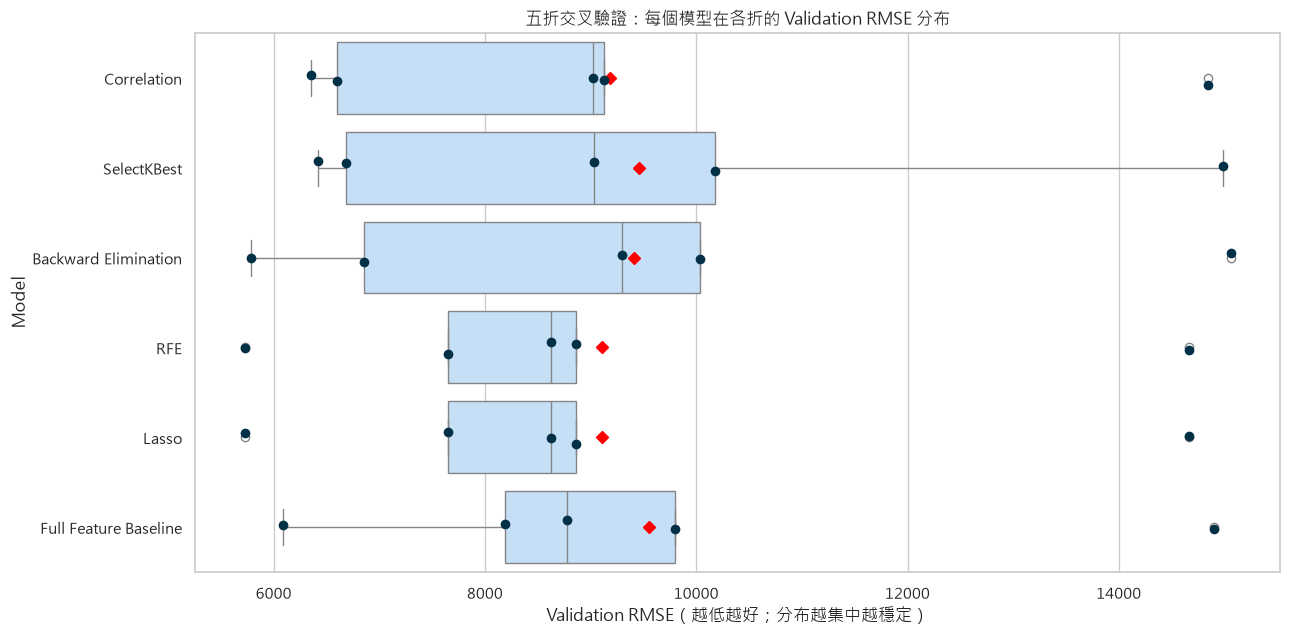

In [23]:
# 用箱型圖與每折資料點呈現模型的 CV RMSE 分布
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=cv_fold_detail_df,
    y="Model",
    x="Validation RMSE",
    color="#bde0fe",
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "red", "markeredgecolor": "red"},
)
sns.stripplot(
    data=cv_fold_detail_df,
    y="Model",
    x="Validation RMSE",
    color="#023047",
    size=7,
    jitter=0.08,
)
plt.title("五折交叉驗證：每個模型在各折的 Validation RMSE 分布")
plt.xlabel("Validation RMSE（越低越好；分布越集中越穩定）")
plt.ylabel("Model")
plt.show()

## 如何閱讀逐折結果與箱型圖？

- 表格每一欄代表一折 Validation RMSE，可觀察模型是否在某一折特別差。
- 箱型圖中央線表示中位數，紅色菱形表示平均值。
- 五個深色點代表五折實際 RMSE。
- 點越靠左表示誤差越低；點越集中表示模型越穩定。
- 若某一折 RMSE 特別高，應檢查該折是否包含特殊或極端公司。

因為每折只有約 8 筆 Validation Data，本資料的 CV 分數仍可能有明顯波動。這正是需要同時報告 Mean 與 Std 的原因。

## 五折 CV 與外部 Test Set 的角色差異

| 資料 | 用途 | 是否可以反覆查看？ |
|---|---|---|
| Fold Training Data | 每折訓練模型 | 可以 |
| Fold Validation Data | 在 Training Set 內比較模型與檢查穩定性 | 可以，但不可直接參與該折訓練 |
| 外部 Test Set | 最後模擬真正未見資料 | 不應反覆用來調整模型 |

五折 CV 不會取代外部 Test Set：

- CV 用於模型開發期間的穩定性檢查與參數選擇。
- Test Set 用於流程完成後的最終泛化評估。

若反覆根據 Test Set 分數修改特徵或參數，Test Set 就會逐漸變成 Validation Set，最終分數會過度樂觀。

# 學習問題 20：為什麼「先選特徵，再做 CV」不夠嚴謹？

## 初步比較目前回答了什麼？

前面的候選模型先使用完整 Training Set 選定特徵，再用 CV 評估固定特徵組合。因此它回答的是：

> 如果特徵組合已經固定，Linear Regression 在不同 Training／Validation 切分下是否穩定？

這個比較適合初步觀察，但 Validation Fold 曾間接參與特徵選擇，CV 分數可能稍微樂觀。

## 三種評估層級

| 層級 | 特徵選擇發生在哪裡？ | 用途與限制 |
|---|---|---|
| 固定特徵組合後做 CV | CV 前，使用完整 Training Set | 適合初步診斷，但可能稍微樂觀 |
| Pipeline + CV | 每一折的 Fold Training Data | 評估完整流程，避免 Validation Fold 洩漏 |
| Nested CV | 內層選方法與參數，外層評估 | 最完整，但 50 筆資料切分後容易非常不穩定 |

## 本專案採用什麼？

本專案以 **Pipeline + 5-Fold CV** 作為主要公平比較，並用 **Repeated 5-Fold CV** 做切分敏感度檢查。Nested CV 僅作為進階觀念，不作為主要結果。

下方固定特徵組合表格與圖形只屬於「初步診斷」，不是最終選模依據。

In [24]:
comparison = pd.DataFrame([
    result for result in evaluations
])

# 排名只用來整理證據，不直接等同最終模型決策
comparison["CV RMSE Rank"] = comparison["CV RMSE Mean"].rank(method="min", ascending=True).astype(int)
comparison["CV Stability Rank"] = comparison["CV RMSE Std"].rank(method="min", ascending=True).astype(int)
comparison["Simplicity Rank"] = comparison["Feature Count"].rank(method="min", ascending=True).astype(int)
best_cv_rmse = comparison["CV RMSE Mean"].min()
comparison["Within 5% of Best CV"] = comparison["CV RMSE Mean"] <= best_cv_rmse * 1.05

# 排序方便閱讀；最後仍需綜合理論依據、穩定性與簡潔性決定
comparison = comparison.sort_values(
    ["CV RMSE Mean", "CV RMSE Std", "Feature Count"],
    ascending=[True, True, True],
).reset_index(drop=True)
comparison.insert(0, "Evidence Order", range(1, len(comparison) + 1))

decision_columns = [
    "Evidence Order", "Model", "Features", "Feature Count",
    "CV RMSE Mean", "CV RMSE Std", "CV MAE Mean", "CV R2 Mean",
    "Within 5% of Best CV",
]
display(comparison[decision_columns].style.format({
    "CV RMSE Mean": "{:,.2f}",
    "CV RMSE Std": "{:,.2f}",
    "CV MAE Mean": "{:,.2f}",
    "CV R2 Mean": "{:.4f}",
}).background_gradient(subset=["CV RMSE Mean", "CV RMSE Std", "CV MAE Mean"], cmap="RdYlGn_r")
  .background_gradient(subset=["CV R2 Mean"], cmap="RdYlGn"))

,Evidence Order,Model,Features,Feature Count,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV R2 Mean,Within 5% of Best CV
0,1,RFE,"R&D Spend, Administration, Marketing Spend",3,"9,104.68","2,991.94","7,157.92",0.9399,True
1,2,Lasso,"R&D Spend, Administration, Marketing Spend",3,"9,104.68","2,991.94","7,157.92",0.9399,True
2,3,Correlation,"R&D Spend, Marketing Spend",2,"9,186.68","3,058.89","7,057.98",0.9416,True
3,4,Backward Elimination,R&D Spend,1,"9,406.58","3,224.41","7,218.15",0.9384,True
4,5,SelectKBest,"R&D Spend, Marketing Spend, State_New York",3,"9,460.92","3,105.37","7,202.96",0.9387,True
5,6,Full Feature Baseline,"R&D Spend, Administration, Marketing Spend, State_Florida, State_New York",5,"9,550.68","2,936.12","7,425.88",0.9340,True


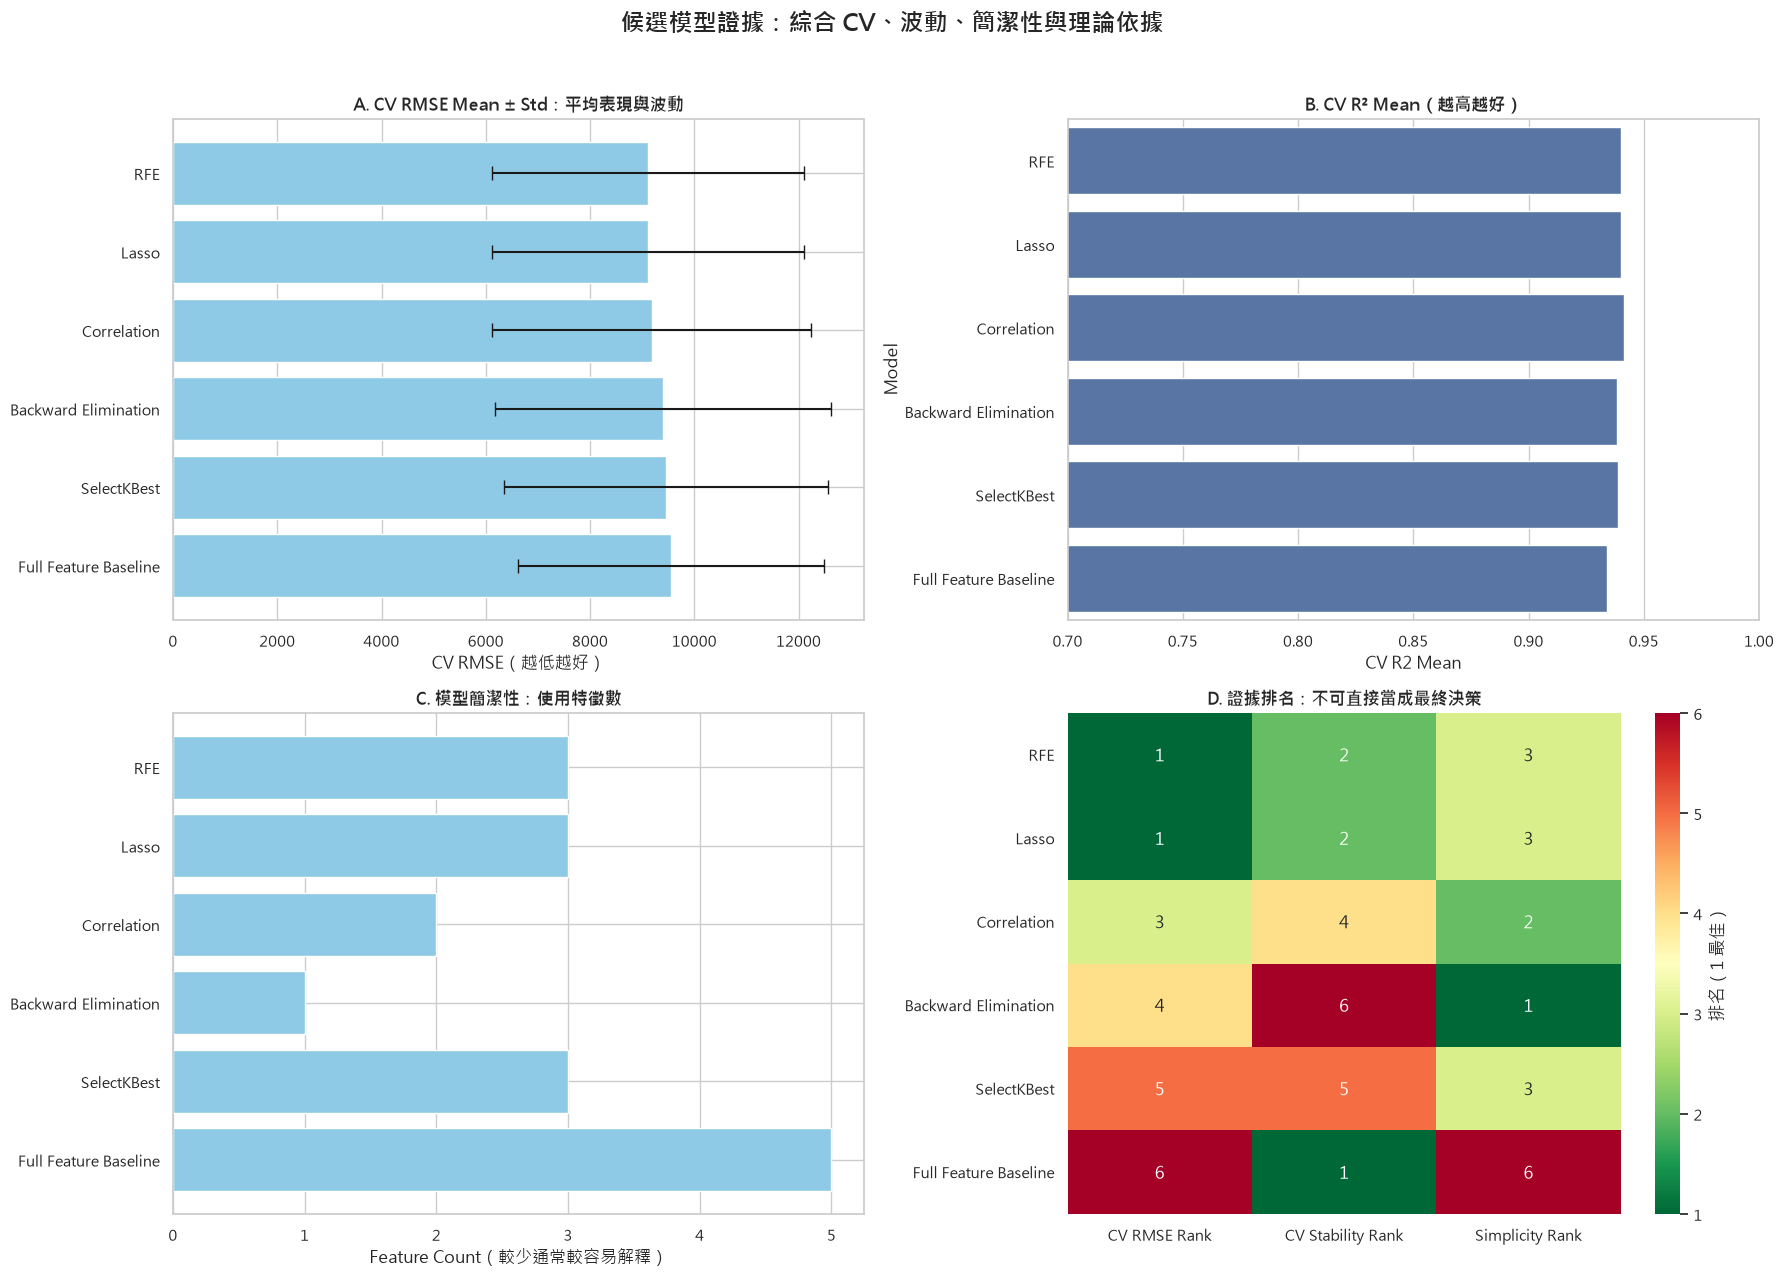

In [25]:
# 更完整的四區塊模型選擇圖
plot_order = comparison["Model"].tolist()
palette = {
    model: "#8ecae6"
    for model in comparison["Model"]
}

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# A. CV RMSE 平均值與波動
cv_plot = comparison.set_index("Model").loc[plot_order]
axes[0, 0].barh(
    cv_plot.index, cv_plot["CV RMSE Mean"], xerr=cv_plot["CV RMSE Std"],
    color=[palette[name] for name in cv_plot.index], capsize=5,
)
axes[0, 0].invert_yaxis()
axes[0, 0].set_title("A. CV RMSE Mean ± Std：平均表現與波動", weight="bold")
axes[0, 0].set_xlabel("CV RMSE（越低越好）")

# B. CV R2
sns.barplot(data=comparison, y="Model", x="CV R2 Mean", order=plot_order, ax=axes[0, 1])
axes[0, 1].set_title("B. CV R² Mean（越高越好）", weight="bold")
axes[0, 1].set_xlim(0.7, 1.0)

# C. 特徵數：簡潔性
axes[1, 0].barh(cv_plot.index, cv_plot["Feature Count"], color=[palette[name] for name in cv_plot.index])
axes[1, 0].invert_yaxis()
axes[1, 0].set_title("C. 模型簡潔性：使用特徵數", weight="bold")
axes[1, 0].set_xlabel("Feature Count（較少通常較容易解釋）")

# D. 證據排名熱圖
rank_columns = ["CV RMSE Rank", "CV Stability Rank", "Simplicity Rank"]
rank_matrix = comparison.set_index("Model")[rank_columns]
sns.heatmap(
    rank_matrix,
    annot=True,
    fmt="d",
    cmap="RdYlGn_r",
    cbar_kws={"label": "排名（1 最佳）"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("D. 證據排名：不可直接當成最終決策", weight="bold")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")

fig.suptitle(
    "候選模型證據：綜合 CV、波動、簡潔性與理論依據",
    fontsize=17,
    weight="bold",
)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 初步固定特徵組合 CV 應如何閱讀？

- 圖中的候選組合是在完整 Training Set 上先選好特徵，再進行 CV。
- 平均 RMSE 可用來初步比較，誤差線可觀察切分波動。
- 排名只整理證據，不能直接視為最終模型決策。
- 因為 Validation Fold 間接參與過特徵選擇，最終結論應以下一題的 `Pipeline + CV` 為主。

# 學習問題 21：如何使用 Pipeline + CV 公平比較特徵篩選方法？

公平比較必須讓每一折只使用 Fold Training Data 執行特徵篩選，再以未參與篩選的 Validation Fold 評分。下方將五種方法都放入 Pipeline，並比較 `k=1` 到全部特徵數。

## 21-1：比較各方法在不同特徵數下的平均表現

先看折線與摘要表，回答：

- 同一個 `k` 下，哪些方法表現接近？
- 增加特徵是否持續改善 RMSE？
- 當多條線重疊時，是否因為選到相同特徵？

In [26]:
# 補充題的第二步：固定特徵數模型之公平效能比較
# 公平比較原則：
# 1. 不使用外部 Test Set。
# 2. 將特徵篩選器與 Linear Regression 放入同一個 Pipeline。
# 3. cross_validate 會讓每一折只用 Fold Training Data 擬合完整 Pipeline。
SELECTION_METHODS = ["Correlation", "SelectKBest", "Backward Elimination", "RFE", "Lasso"]
K_VALUES = range(1, X_train.shape[1] + 1)
pipeline_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


class FixedKFeatureSelector(BaseEstimator, TransformerMixin):
    # Pipeline 每次 fit 時，只使用該折 Training Data 選擇固定 k 個特徵。

    def __init__(self, method="Correlation", k=2, random_state=42):
        self.method = method
        self.k = k
        self.random_state = random_state

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        if self.method == "Correlation":
            scores = X.apply(lambda column: column.corr(pd.Series(y, index=X.index))).abs()
            self.selected_features_ = scores.nlargest(self.k).index.tolist()

        elif self.method == "SelectKBest":
            selector = SelectKBest(score_func=f_regression, k=self.k).fit(X, y)
            self.selected_features_ = X.columns[selector.get_support()].tolist()

        elif self.method == "Backward Elimination":
            self.selected_features_ = X.columns.tolist()
            while len(self.selected_features_) > self.k:
                ols = sm.OLS(
                    y,
                    sm.add_constant(X[self.selected_features_], has_constant="add"),
                ).fit()
                self.selected_features_.remove(ols.pvalues.drop("const").idxmax())

        else:
            X_scaled = StandardScaler().fit_transform(X)
            if self.method == "RFE":
                selector = RFE(
                    LinearRegression(), n_features_to_select=self.k
                ).fit(X_scaled, y)
                self.selected_features_ = X.columns[selector.support_].tolist()
            elif self.method == "Lasso":
                selector = LassoCV(
                    cv=5, random_state=self.random_state, max_iter=100_000
                ).fit(X_scaled, y)
                scores = pd.Series(selector.coef_, index=X.columns).abs()
                self.selected_features_ = scores.nlargest(self.k).index.tolist()
            else:
                raise ValueError(f"Unknown method: {self.method}")
        return self

    def transform(self, X):
        return pd.DataFrame(X).loc[:, self.selected_features_]


fixed_k_cv_rows = []
for k in K_VALUES:
    for method in SELECTION_METHODS:
        selection_pipeline = Pipeline([
            ("selector", FixedKFeatureSelector(
                method=method, k=k, random_state=RANDOM_STATE
            )),
            ("model", LinearRegression()),
        ])
        scores = cross_validate(
            selection_pipeline,
            X_train,
            y_train,
            cv=pipeline_cv,
            scoring="neg_root_mean_squared_error",
            return_estimator=True,
        )
        for fold, (rmse_score, estimator) in enumerate(
            zip(scores["test_score"], scores["estimator"]), start=1
        ):
            fixed_k_cv_rows.append({
                "Method": method,
                "Feature Count": k,
                "Fold": fold,
                "Selected Features": ", ".join(
                    estimator.named_steps["selector"].selected_features_
                ),
                "Validation RMSE": -rmse_score,
            })

fixed_k_cv_detail = pd.DataFrame(fixed_k_cv_rows)
fixed_k_cv_detail["Feature Set"] = fixed_k_cv_detail["Selected Features"].apply(
    lambda value: " | ".join(sorted(value.split(", ")))
)
fixed_k_cv_summary = (
    fixed_k_cv_detail
    .groupby(["Method", "Feature Count"])["Validation RMSE"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "CV RMSE Mean", "std": "CV RMSE Std"})
)

display(
    fixed_k_cv_summary.pivot(
        index="Feature Count", columns="Method", values="CV RMSE Mean"
    ).style.format("{:,.2f}").background_gradient(cmap="RdYlGn_r", axis=None)
)

Method,Backward Elimination,Correlation,Lasso,RFE,SelectKBest
Feature Count,,,,,
1,"9,406.58","9,406.58","9,406.58","9,406.58","9,406.58"
2,"9,396.08","9,186.68","9,186.68","9,186.68","9,186.68"
3,"9,104.68","9,362.47","9,290.41","9,104.68","9,362.47"
4,"9,306.79","9,485.35","9,299.00","9,306.79","9,485.35"
5,"9,550.68","9,550.68","9,550.68","9,550.68","9,550.68"


## 21-2：各方法實際選到了哪些特徵？

效能相同不一定代表方法原理相同。若不同方法在同一折選到相同特徵集合，後續又使用相同 Linear Regression，RMSE 必然相同。下方表格用來檢查特徵集合與選取穩定性。

In [27]:
# 各方法在每個 k、每一折實際選取的特徵集合
feature_selection_by_fold = fixed_k_cv_detail.pivot(
    index=["Feature Count", "Fold"],
    columns="Method",
    values="Feature Set",
)
display(feature_selection_by_fold)

# 摘要：每個方法與 k 最常出現的特徵集合，以及五折中出現幾次
feature_selection_frequency = (
    fixed_k_cv_detail
    .groupby(["Method", "Feature Count", "Feature Set"])
    .size()
    .reset_index(name="Fold Count")
    .sort_values(
        ["Feature Count", "Method", "Fold Count", "Feature Set"],
        ascending=[True, True, False, True],
    )
)
most_common_feature_sets = (
    feature_selection_frequency
    .drop_duplicates(["Method", "Feature Count"])
    .rename(columns={
        "Feature Set": "Most Common Feature Set",
        "Fold Count": "Appeared in Folds",
    })
)
display(most_common_feature_sets)

# 專門檢查 RFE 與 Lasso：同一個 k 中，有幾折選到完全相同的特徵集合？
rfe_lasso_detail = fixed_k_cv_detail[
    fixed_k_cv_detail["Method"].isin(["RFE", "Lasso"])
].pivot(
    index=["Feature Count", "Fold"],
    columns="Method",
    values=["Feature Set", "Validation RMSE"],
).reset_index()
rfe_lasso_detail["Same Feature Set"] = (
    rfe_lasso_detail[("Feature Set", "RFE")]
    == rfe_lasso_detail[("Feature Set", "Lasso")]
)
rfe_lasso_comparison = pd.DataFrame({
    "Feature Count": list(K_VALUES),
    "Same Feature Set Folds": [
        rfe_lasso_detail.loc[
            rfe_lasso_detail["Feature Count"] == k, "Same Feature Set"
        ].sum()
        for k in K_VALUES
    ],
    "RFE CV RMSE Mean": [
        fixed_k_cv_summary.query("Method == 'RFE' and `Feature Count` == @k")[
            "CV RMSE Mean"
        ].iloc[0]
        for k in K_VALUES
    ],
    "Lasso CV RMSE Mean": [
        fixed_k_cv_summary.query("Method == 'Lasso' and `Feature Count` == @k")[
            "CV RMSE Mean"
        ].iloc[0]
        for k in K_VALUES
    ],
})
rfe_lasso_comparison["RMSE Difference"] = (
    rfe_lasso_comparison["Lasso CV RMSE Mean"]
    - rfe_lasso_comparison["RFE CV RMSE Mean"]
)
display(rfe_lasso_comparison.style.format({
    "RFE CV RMSE Mean": "{:,.2f}",
    "Lasso CV RMSE Mean": "{:,.2f}",
    "RMSE Difference": "{:,.2f}",
}))

Method                                           Backward Elimination  \
Feature Count Fold                                                      
1             1                                             R&D Spend   
              2                                             R&D Spend   
              3                                             R&D Spend   
              4                                             R&D Spend   
              5                                             R&D Spend   
2             1                           Marketing Spend | R&D Spend   
              2                           Marketing Spend | R&D Spend   
              3                           Marketing Spend | R&D Spend   
              4                           Marketing Spend | R&D Spend   
              5                            Administration | R&D Spend   
3             1          Administration | Marketing Spend | R&D Spend   
              2          Administration | Marketing Spend | R&D Spend   
              3          Administration | Marketing Spend | R&D Spend   
              4          Administration | Marketing Spend | R&D Spend   
              5          Administration | Marketing Spend | R&D Spend   
4             1     Administration | Marketing Spend | R&D Spend |...   
              2     Administration | Marketing Spend | R&D Spend |...   
              3     Administration | Marketing Spend | R&D Spend |...   
              4     Administration | Marketing Spend | R&D Spend |...   
              5     Administration | Marketing Spend | R&D Spend |...   
5             1     Administration | Marketing Spend | R&D Spend |...   
              2     Administration | Marketing Spend | R&D Spend |...   
              3     Administration | Marketing Spend | R&D Spend |...   
              4     Administration | Marketing Spend | R&D Spend |...   
              5     Administration | Marketing Spend | R&D Spend |...   

Method                                                    Correlation  \
Feature Count Fold                                                      
1             1                                             R&D Spend   
              2                                             R&D Spend   
              3                                             R&D Spend   
              4                                             R&D Spend   
              5                                             R&D Spend   
2             1                           Marketing Spend | R&D Spend   
              2                           Marketing Spend | R&D Spend   
              3                           Marketing Spend | R&D Spend   
              4                           Marketing Spend | R&D Spend   
              5                           Marketing Spend | R&D Spend   
3             1           Marketing Spend | R&D Spend | State_Florida   
              2          Marketing Spend | R&D Spend | State_New York   
              3          Marketing Spend | R&D Spend | State_New York   
              4          Marketing Spend | R&D Spend | State_New York   
              5           Marketing Spend | R&D Spend | State_Florida   
4             1     Administration | Marketing Spend | R&D Spend |...   
              2     Administration | Marketing Spend | R&D Spend |...   
              3     Administration | Marketing Spend | R&D Spend |...   
              4     Marketing Spend | R&D Spend | State_Florida | ...   
              5     Administration | Marketing Spend | R&D Spend |...   
5             1     Administration | Marketing Spend | R&D Spend |...   
              2     Administration | Marketing Spend | R&D Spend |...   
              3     Administration | Marketing Spend | R&D Spend |...   
              4     Administration | Marketing Spend | R&D Spend |...   
              5     Administration | Marketing Spend | R&D Spend |...   

Method                                                  

,Method,Feature Count,Most Common Feature Set,Appeared in Folds
0,Backward Elimination,1,R&D Spend,5
7,Correlation,1,R&D Spend,5
15,Lasso,1,R&D Spend,5
21,RFE,1,R&D Spend,5
27,SelectKBest,1,R&D Spend,5
2,Backward Elimination,2,Marketing Spend | R&D Spend,4
8,Correlation,2,Marketing Spend | R&D Spend,5
16,Lasso,2,Marketing Spend | R&D Spend,5
22,RFE,2,Marketing Spend | R&D Spend,5
28,SelectKBest,2,Marketing Spend | R&D Spend,5


,Feature Count,Same Feature Set Folds,RFE CV RMSE Mean,Lasso CV RMSE Mean,RMSE Difference
0,1,5,"9,406.58","9,406.58",0.00
1,2,5,"9,186.68","9,186.68",0.00
2,3,4,"9,104.68","9,290.41",185.73
3,4,4,"9,306.79","9,299.00",-7.79
4,5,5,"9,550.68","9,550.68",0.00


## 21-3：單次 5-Fold CV 的初步結論

下表先整理每種方法在單次 5-Fold CV 中表現最佳的 `k`。這仍只是某一種切分方式的結果，不能直接宣告唯一勝者。

In [28]:
# 依完整 Pipeline + CV 證據整理每個方法的最佳 k
pipeline_method_best = (
    fixed_k_cv_summary
    .sort_values(["Method", "CV RMSE Mean", "CV RMSE Std"])
    .drop_duplicates("Method")
    .sort_values(["CV RMSE Mean", "CV RMSE Std"])
    .reset_index(drop=True)
)
pipeline_method_best["CV RMSE Difference from Best"] = (
    pipeline_method_best["CV RMSE Mean"] - pipeline_method_best["CV RMSE Mean"].min()
)
display(pipeline_method_best.style.format({
    "CV RMSE Mean": "{:,.2f}",
    "CV RMSE Std": "{:,.2f}",
    "CV RMSE Difference from Best": "{:,.2f}",
}))

,Method,Feature Count,CV RMSE Mean,CV RMSE Std,CV RMSE Difference from Best
0,Backward Elimination,3,"9,104.68","3,345.09",0.00
1,RFE,3,"9,104.68","3,345.09",0.00
2,Correlation,2,"9,186.68","3,419.94",82.00
3,Lasso,2,"9,186.68","3,419.94",82.00
4,SelectKBest,2,"9,186.68","3,419.94",82.00


# 學習問題 22：單次 CV 與 Repeated CV 結論不同時，如何選模型？

單次 5-Fold CV 只代表一種切分。對小樣本資料，應改用多次不同切分檢查結論是否穩定。Repeated CV 不是為了製造更漂亮的分數，而是用來觀察模型排名是否會因切分改變。

## 22-1：Repeated CV 敏感度分析

In [29]:
# 小樣本敏感度檢查：重複多種 CV 切分，避免結論只依賴 random_state=42 的單次五折
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
repeated_cv_rows = []
for k in K_VALUES:
    for method in SELECTION_METHODS:
        selection_pipeline = Pipeline([
            ("selector", FixedKFeatureSelector(
                method=method, k=k, random_state=RANDOM_STATE
            )),
            ("model", LinearRegression()),
        ])
        scores = cross_validate(
            selection_pipeline,
            X_train,
            y_train,
            cv=repeated_cv,
            scoring="neg_root_mean_squared_error",
        )
        repeated_cv_rows.append({
            "Method": method,
            "Feature Count": k,
            "Repeated CV RMSE Mean": -scores["test_score"].mean(),
            "Repeated CV RMSE Std": scores["test_score"].std(),
        })

repeated_cv_summary = pd.DataFrame(repeated_cv_rows)
repeated_method_best = (
    repeated_cv_summary
    .sort_values(["Method", "Repeated CV RMSE Mean"])
    .drop_duplicates("Method")
    .sort_values("Repeated CV RMSE Mean")
    .reset_index(drop=True)
)
display(repeated_method_best.style.format({
    "Repeated CV RMSE Mean": "{:,.2f}",
    "Repeated CV RMSE Std": "{:,.2f}",
}))

,Method,Feature Count,Repeated CV RMSE Mean,Repeated CV RMSE Std
0,Correlation,2,"9,644.40","3,170.90"
1,SelectKBest,2,"9,644.40","3,170.90"
2,Lasso,2,"9,652.86","3,185.93"
3,RFE,2,"9,740.42","3,250.35"
4,Backward Elimination,1,"9,862.04","3,446.15"


## 22-2：將單次 Pipeline CV 畫成折線圖

折線圖用於觀察方法與特徵數的關係；最終結論仍必須搭配 Repeated CV 與實際特徵集合閱讀。

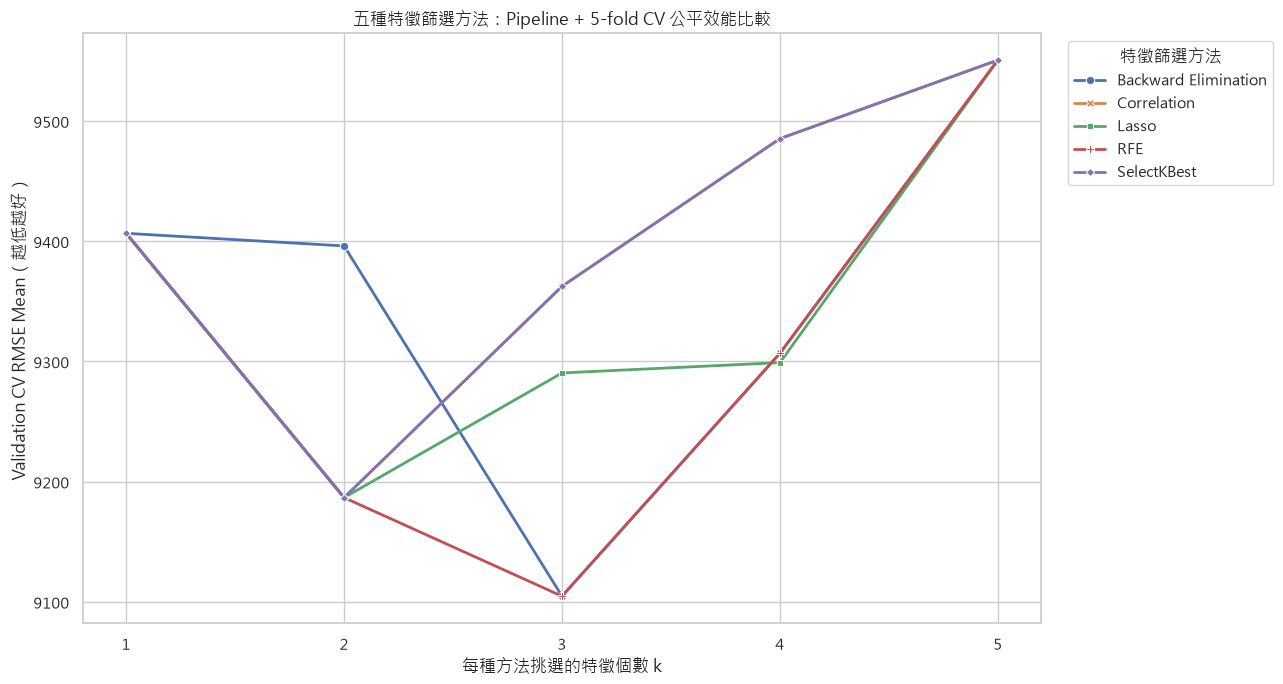

In [30]:
plt.figure(figsize=(13, 7))
sns.lineplot(
    data=fixed_k_cv_summary,
    x="Feature Count",
    y="CV RMSE Mean",
    hue="Method",
    style="Method",
    markers=True,
    dashes=False,
    linewidth=2,
)
plt.xticks(list(K_VALUES))
plt.title("五種特徵篩選方法：Pipeline + 5-fold CV 公平效能比較")
plt.xlabel("每種方法挑選的特徵個數 k")
plt.ylabel("Validation CV RMSE Mean（越低越好）")
plt.legend(title="特徵篩選方法", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 22-3：本專案的模型選擇結論

### 觀察到的證據

1. 單次 Pipeline + 5-Fold CV 偏向 `RFE/Backward Elimination, k=3`。
2. Repeated 5-Fold CV 偏向 `Correlation/SelectKBest, k=2`。
3. 多個方法經常選到相同特徵，因此方法名稱不同，不代表最後建立的模型不同。
4. 不同切分會改變方法排名，表示本資料沒有穩定且唯一的特徵篩選方法勝者。
5. `R&D Spend` 與 `Marketing Spend` 在多種方法與多次切分中反覆被選取。

### 最終決策

本專案選擇 **Consensus Two-Feature Model**：

- 特徵：`R&D Spend`、`Marketing Spend`
- 理由：多種方法支持、Repeated CV 表現合理、模型簡潔且容易解釋
- 不代表：Correlation 是最佳方法
- 仍存在的不確定性：樣本只有 50 筆，新增資料後最佳特徵組合可能改變

> 最準確的說法不是「某方法獲勝」，而是「目前證據支持這個兩特徵模型作為合理且簡潔的最終方案」。

In [31]:
# 不將最終模型命名為某一種特徵篩選方法。
# Repeated CV 與多種方法共同支持 R&D Spend + Marketing Spend 這組特徵。
best_name = "Consensus Two-Feature Model"
best_features = ["R&D Spend", "Marketing Spend"]
best_model = LinearRegression().fit(X_train[best_features], y_train)

coefficient_table = pd.DataFrame({
    "Feature": best_features,
    "Coefficient": best_model.coef_,
})
print("最終選定模型：", best_name)
print("特徵：", best_features)
print("Intercept：", best_model.intercept_)
display(coefficient_table)

最終選定模型： Consensus Two-Feature Model
特徵： ['R&D Spend', 'Marketing Spend']
Intercept： 45542.392477514295


,Feature,Coefficient
0,R&D Spend,0.7834
1,Marketing Spend,0.0392


# 學習問題 23：最終模型如何使用外部 Test Set 評估？

Evaluation 的目的不是只宣布一個最低分，而是回答「模型表現如何、結果是否穩定、能否合理解釋，以及目前證據有哪些限制」。

## 小樣本情境下的 Evaluation 觀點

本資料的 CV 與 Test 評估都建立在很少的觀測值上，因此兩者皆具有較高的不確定性：

- 5-Fold CV 的每一折 Validation Data 約只有 8 筆，少數觀測值就可能明顯改變 RMSE。
- 外部 Test Set 只有 10 筆，單次 Test 分數也可能受到特定切分影響。
- CV 平均最佳但 Test 較差，或 CV 稍差但 Test 較好，都可能只是抽樣波動，不能單憑一次結果判定方法對錯。

因此，最終報告應同時呈現 CV 平均值、CV 標準差、逐折結果與一次外部 Test 結果，並清楚說明小樣本限制。外部 Test 結果可用於評估選定模型的泛化表現，但不可在查看後回頭改選模型。

## 本專案的 Evaluation 判讀順序

1. **先看 Training Set 內的 CV 證據：** 同時閱讀 `CV RMSE Mean` 與 `CV RMSE Std`，建立表現合理的候選範圍。
2. **再看誤差的實務大小：** MAE 表示一般情況下平均差多少 Profit；RMSE 對少數大誤差懲罰較重。
3. **檢查解釋力：** R² 越高代表模型可解釋的 Profit 變異比例越高；Adjusted R² 會考慮特徵數，避免只靠增加特徵灌高 R²。
4. **檢查可解釋性：** 係數方向是否合理、特徵是否能在預測時取得，以及模型是否足夠簡潔。
5. **最後才報告外部 Test Set：** Test RMSE、MAE、R² 用於描述選定模型面對未見資料的結果，不應回頭拿來更換模型。

## 如何解讀本次結果

- 單次 Pipeline + 5-Fold CV 偏向 `RFE/Backward Elimination, k=3`，但 Repeated CV 偏向由 Correlation 與 SelectKBest 都能選出的兩特徵組合。這證明小樣本下不存在穩定且唯一的方法勝者。
- 本學習專案最終選擇 `Consensus Two-Feature Model`，使用 `R&D Spend` 與 `Marketing Spend`。這是多種方法與重複切分共同支持的特徵集合，不代表 Correlation 被認定為最佳方法。
- Correlation 在此資料上表現良好，是因為 Profit 主要由少數強線性特徵驅動；它仍只適合作為簡單 Filter Method 與 Baseline，不能因此推廣為普遍最佳方法。
- `R&D Spend` 係數為正且幅度最大，代表在其他變數固定時，它與 Profit 有最強的正向線性預測關係。
- `Administration` 係數略為負、`Marketing Spend` 係數略為正；這些是條件關聯，不可直接解讀為增加或刪減預算必然造成 Profit 改變。
- CV 平均值反映模型在不同訓練／驗證切分下的一般表現；CV 標準差與逐折範圍則反映小樣本造成的波動。
- 本資料只有 50 筆，外部 Test Set 只有 10 筆，因此單次 Test 分數可能對切分非常敏感。結論適合教學與初步探索，不足以直接支援真實投資決策。
- Test 結果與 CV 結果若不一致，應解讀為模型選擇不確定性較高，並建議蒐集更多資料或使用不同切分做敏感度分析，而不是回頭挑選 Test 分數較好的候選模型。

In [32]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    LinearRegression(),
    X_train[best_features],
    y_train,
    cv=cv,
    scoring={"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"},
)

# 完整流程與候選組合已選定後，外部 Test Set 只在此評估一次。
final_test_prediction = best_model.predict(X_test[best_features])
final_test_r2 = r2_score(y_test, final_test_prediction)
final_test_n, final_test_p = len(y_test), len(best_features)
final_test_adjusted_r2 = (
    1 - (1 - final_test_r2) * (final_test_n - 1) / (final_test_n - final_test_p - 1)
    if final_test_n - final_test_p - 1 > 0 else np.nan
)
final_test_metrics = {
    "MAE": mean_absolute_error(y_test, final_test_prediction),
    "RMSE": mean_squared_error(y_test, final_test_prediction) ** 0.5,
    "R2": final_test_r2,
    "Adjusted R2": final_test_adjusted_r2,
}
evaluation_summary = pd.DataFrame({
    "指標": [
        "Test MAE", "Test RMSE", "Test R2", "Test Adjusted R2",
        "5-fold CV MAE Mean", "5-fold CV RMSE Mean",
        "5-fold CV RMSE Std", "5-fold CV R2 Mean",
    ],
    "數值": [
        final_test_metrics["MAE"], final_test_metrics["RMSE"], final_test_metrics["R2"],
        final_test_metrics["Adjusted R2"], -cv_scores["test_MAE"].mean(),
        -cv_scores["test_RMSE"].mean(), cv_scores["test_RMSE"].std(),
        cv_scores["test_R2"].mean(),
    ],
    "用途": [
        "最終報告：平均絕對預測誤差",
        "最終報告：對大誤差較敏感",
        "最終報告：Test Profit 變異解釋比例",
        "最終報告：考慮特徵數後的解釋力",
        "開發參考：不同切分下的平均絕對誤差",
        "開發參考：不同切分下的平均 RMSE",
        "穩定性：越小代表不同切分結果越接近",
        "開發參考：不同切分下的平均解釋力",
    ],
})
display(evaluation_summary.style.format({"數值": "{:,.4f}"}))

fold_evaluation = pd.DataFrame({
    "Fold": range(1, 6),
    "Validation MAE": -cv_scores["test_MAE"],
    "Validation RMSE": -cv_scores["test_RMSE"],
    "Validation R2": cv_scores["test_R2"],
})
display(fold_evaluation.style.format({
    "Validation MAE": "{:,.2f}",
    "Validation RMSE": "{:,.2f}",
    "Validation R2": "{:.4f}",
}))

print(f"Evaluation 結論：{best_name} 是綜合 CV、理論依據與簡潔性後選定的模型。")
print(f"平均每筆 Validation 絕對誤差約 {-cv_scores['test_MAE'].mean():,.0f} Profit。")
print(f"Validation RMSE 平均約 {-cv_scores['test_RMSE'].mean():,.0f}，標準差約 {cv_scores['test_RMSE'].std():,.0f}。")
print(f"外部 Test RMSE 為 {final_test_metrics['RMSE']:,.0f}，僅作最終一次報告，不參與選模。")
print("CV 與 Test 若不一致，應視為小樣本下的模型選擇不確定性，而不是回頭依 Test 更換模型。")

,指標,數值,用途
0,Test MAE,"6,469.1817",最終報告：平均絕對預測誤差
1,Test RMSE,"8,206.3288",最終報告：對大誤差較敏感
2,Test R2,0.9168,最終報告：Test Profit 變異解釋比例
3,Test Adjusted R2,0.8931,最終報告：考慮特徵數後的解釋力
4,5-fold CV MAE Mean,"7,057.9822",開發參考：不同切分下的平均絕對誤差
5,5-fold CV RMSE Mean,"9,186.6804",開發參考：不同切分下的平均 RMSE
6,5-fold CV RMSE Std,"3,058.8881",穩定性：越小代表不同切分結果越接近
7,5-fold CV R2 Mean,0.9416,開發參考：不同切分下的平均解釋力


,Fold,Validation MAE,Validation RMSE,Validation R2
0,1,"7,682.29","9,122.84",0.9601
1,2,"7,626.97","9,019.77",0.9518
2,3,"10,530.52","14,843.61",0.8941
3,4,"4,845.15","6,352.17",0.9688
4,5,"4,604.98","6,595.01",0.9333


Evaluation 結論：Consensus Two-Feature Model 是綜合 CV、理論依據與簡潔性後選定的模型。
平均每筆 Validation 絕對誤差約 7,058 Profit。
Validation RMSE 平均約 9,187，標準差約 3,059。
外部 Test RMSE 為 8,206，僅作最終一次報告，不參與選模。
CV 與 Test 若不一致，應視為小樣本下的模型選擇不確定性，而不是回頭依 Test 更換模型。


# 學習問題 24：Deployment 階段如何呈現？

本學習專案可以用函式作為簡易部署。使用者輸入原始四個欄位，函式會套用訓練好的 One-Hot Encoder，再交給最佳模型預測。

In [33]:
def predict_profit(rd_spend, administration, marketing_spend, state):
    raw = pd.DataFrame([{
        "R&D Spend": rd_spend,
        "Administration": administration,
        "Marketing Spend": marketing_spend,
        "State": state,
    }])
    state_values = encoder.transform(raw[CATEGORICAL_FEATURES])
    encoded = pd.concat([
        raw[NUMERIC_FEATURES].reset_index(drop=True),
        pd.DataFrame(state_values, columns=state_names),
    ], axis=1)
    return float(best_model.predict(encoded[best_features])[0])

example_prediction = predict_profit(
    rd_spend=100_000,
    administration=120_000,
    marketing_spend=200_000,
    state="New York",
)
print(f"預測 Profit：{example_prediction:,.2f}")

預測 Profit：131,727.78

# 學習問題 25：專案總結與學習反思

## CRISP-DM 六階段總結

1. **Business Understanding：** 預測 Profit，協助資源配置
2. **Data Understanding：** 50 筆小型資料，R&D Spend 與 Profit 關係最強
3. **Data Preparation：** 先切分資料，再擬合 One-Hot Encoder，避免資料外洩
4. **Modeling：** 使用五種特徵篩選方法建立 Linear Regression
5. **Evaluation：** 比較 MAE、MSE、RMSE、R²、Adjusted R² 與交叉驗證
6. **Deployment：** 提供簡易預測函式

## 重要限制

- 樣本只有 50 筆，測試集結果容易受到切分影響
- 線性模型無法自動捕捉複雜非線性關係
- 相關與模型係數不代表因果
- 真實部署前應蒐集更多新資料並持續監控誤差

# 補充說明：五個延伸問題與答案

以下五題不再只是自我練習，而是用來補充說明模型結果為何會改變、如何檢查模型，以及新增資料可能帶來的價值。前 1 至 4 題由下方程式實際計算；第 5 題屬於商業與資料設計的推論。

In [34]:
# 補充題 1：修改 random_state，最佳模型是否改變？
# 每個 random_state 都重新切 Train/Test、重新編碼、重新篩選特徵，
# 並只使用 Training Set 內的 CV RMSE 選擇候選模型。
def compare_models_for_random_state(seed):
    X_train_raw_seed, _, y_train_seed, _ = train_test_split(
        X_raw, y, test_size=0.2, random_state=seed
    )
    seed_encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    seed_encoder.fit(X_train_raw_seed[CATEGORICAL_FEATURES])
    seed_state_names = seed_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()

    def transform_seed(raw):
        return pd.concat([
            raw[NUMERIC_FEATURES].reset_index(drop=True),
            pd.DataFrame(
                seed_encoder.transform(raw[CATEGORICAL_FEATURES]),
                columns=seed_state_names,
            ),
        ], axis=1)

    X_train_seed = transform_seed(X_train_raw_seed)
    y_train_seed = y_train_seed.reset_index(drop=True)

    seed_corr = X_train_seed.apply(lambda column: column.corr(y_train_seed)).abs()
    corr_seed_features = seed_corr[seed_corr >= 0.5].index.tolist() or [seed_corr.idxmax()]

    kbest_seed = SelectKBest(f_regression, k=min(3, X_train_seed.shape[1])).fit(
        X_train_seed, y_train_seed
    )
    kbest_seed_features = X_train_seed.columns[kbest_seed.get_support()].tolist()

    backward_seed_features = X_train_seed.columns.tolist()
    while len(backward_seed_features) > 1:
        seed_ols = sm.OLS(
            y_train_seed,
            sm.add_constant(X_train_seed[backward_seed_features], has_constant="add"),
        ).fit()
        worst_feature = seed_ols.pvalues.drop("const").idxmax()
        if seed_ols.pvalues[worst_feature] <= 0.05:
            break
        backward_seed_features.remove(worst_feature)

    seed_scaled = StandardScaler().fit_transform(X_train_seed)
    rfe_seed = RFE(LinearRegression(), n_features_to_select=min(3, X_train_seed.shape[1]))
    rfe_seed.fit(seed_scaled, y_train_seed)
    rfe_seed_features = X_train_seed.columns[rfe_seed.support_].tolist()

    lasso_seed = LassoCV(cv=5, random_state=seed, max_iter=100_000).fit(
        seed_scaled, y_train_seed
    )
    lasso_seed_scores = pd.Series(lasso_seed.coef_, index=X_train_seed.columns).abs()
    lasso_seed_features = lasso_seed_scores[lasso_seed_scores > 1e-8].index.tolist()
    if not lasso_seed_features:
        lasso_seed_features = [lasso_seed_scores.idxmax()]

    seed_candidates = {
        "Correlation": corr_seed_features,
        "SelectKBest": kbest_seed_features,
        "Backward Elimination": backward_seed_features,
        "RFE": rfe_seed_features,
        "Lasso": lasso_seed_features,
        "Full Feature Baseline": X_train_seed.columns.tolist(),
    }
    seed_cv = KFold(n_splits=5, shuffle=True, random_state=seed)
    rows = []
    for method, features in seed_candidates.items():
        scores = cross_validate(
            LinearRegression(), X_train_seed[features], y_train_seed,
            cv=seed_cv, scoring="neg_root_mean_squared_error",
        )
        rows.append({
            "random_state": seed,
            "Model": method,
            "Features": ", ".join(features),
            "CV RMSE Mean": -scores["test_score"].mean(),
        })
    return min(rows, key=lambda row: row["CV RMSE Mean"])


random_state_answer = pd.DataFrame([
    compare_models_for_random_state(seed) for seed in [0, 1, 7, 21, 42]
])
display(random_state_answer.style.format({
    "CV RMSE Mean": "{:,.2f}",
}))
print("答案 1：最佳模型或選取特徵可能隨 random_state 改變，因為本資料只有 50 筆，切分差異會明顯影響篩選與評估。")

,random_state,Model,Features,CV RMSE Mean
0,0,Correlation,"R&D Spend, Marketing Spend","9,482.34"
1,1,Correlation,"R&D Spend, Marketing Spend","9,349.23"
2,7,SelectKBest,"R&D Spend, Marketing Spend, State_Florida","9,310.97"
3,21,Correlation,"R&D Spend, Marketing Spend","9,748.12"
4,42,RFE,"R&D Spend, Administration, Marketing Spend","9,104.68"


答案 1：最佳模型或選取特徵可能隨 random_state 改變，因為本資料只有 50 筆，切分差異會明顯影響篩選與評估。


In [35]:
# 補充題 2、3：比較 Correlation 門檻，以及 SelectKBest 的不同 k
def supplementary_evaluation(label, features):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        LinearRegression(), X_train[features], y_train, cv=cv,
        scoring={"RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error"},
    )
    return {
        "設定": label,
        "特徵": ", ".join(features),
        "特徵數": len(features),
        "CV RMSE Mean": -scores["test_RMSE"].mean(),
        "CV MAE Mean": -scores["test_MAE"].mean(),
    }


correlation_answers = []
for threshold in [0.5, 0.3]:
    features = train_corr.abs()[train_corr.abs() >= threshold].index.tolist()
    correlation_answers.append(
        supplementary_evaluation(f"Correlation threshold={threshold}", features)
    )
correlation_answer_df = pd.DataFrame(correlation_answers)
display(correlation_answer_df.style.format({
    "CV RMSE Mean": "{:,.2f}", "CV MAE Mean": "{:,.2f}",
}))
print("答案 2：若兩個門檻選到相同特徵，所有分數就會相同；降低門檻不保證模型一定改善。")

kbest_answers = []
for k in [1, 2, 4]:
    selector = SelectKBest(score_func=f_regression, k=k).fit(X_train, y_train)
    features = X_train.columns[selector.get_support()].tolist()
    kbest_answers.append(supplementary_evaluation(f"SelectKBest k={k}", features))
kbest_answer_df = pd.DataFrame(kbest_answers)
display(kbest_answer_df.style.format({
    "CV RMSE Mean": "{:,.2f}", "CV MAE Mean": "{:,.2f}",
}))
best_k_row = kbest_answer_df.loc[kbest_answer_df["CV RMSE Mean"].idxmin()]
print(f"答案 3：在本次 Training Set CV 比較中，{best_k_row['設定']} 的平均 CV RMSE 最低。")
print("但 k 的最終決定還應考慮波動、理論依據與簡潔性，不能只取 CV 最低者，更不能使用 Test RMSE 選 k。")

,設定,特徵,特徵數,CV RMSE Mean,CV MAE Mean
0,Correlation threshold=0.5,"R&D Spend, Marketing Spend",2,"9,186.68","7,057.98"
1,Correlation threshold=0.3,"R&D Spend, Marketing Spend",2,"9,186.68","7,057.98"


答案 2：若兩個門檻選到相同特徵，所有分數就會相同；降低門檻不保證模型一定改善。


,設定,特徵,特徵數,CV RMSE Mean,CV MAE Mean
0,SelectKBest k=1,R&D Spend,1,"9,406.58","7,218.15"
1,SelectKBest k=2,"R&D Spend, Marketing Spend",2,"9,186.68","7,057.98"
2,SelectKBest k=4,"R&D Spend, Marketing Spend, State_Florida, State_New York",4,"9,655.47","7,367.19"


答案 3：在本次 Training Set CV 比較中，SelectKBest k=2 的平均 CV RMSE 最低。
但 k 的最終決定還應考慮波動、理論依據與簡潔性，不能只取 CV 最低者，更不能使用 Test RMSE 選 k。


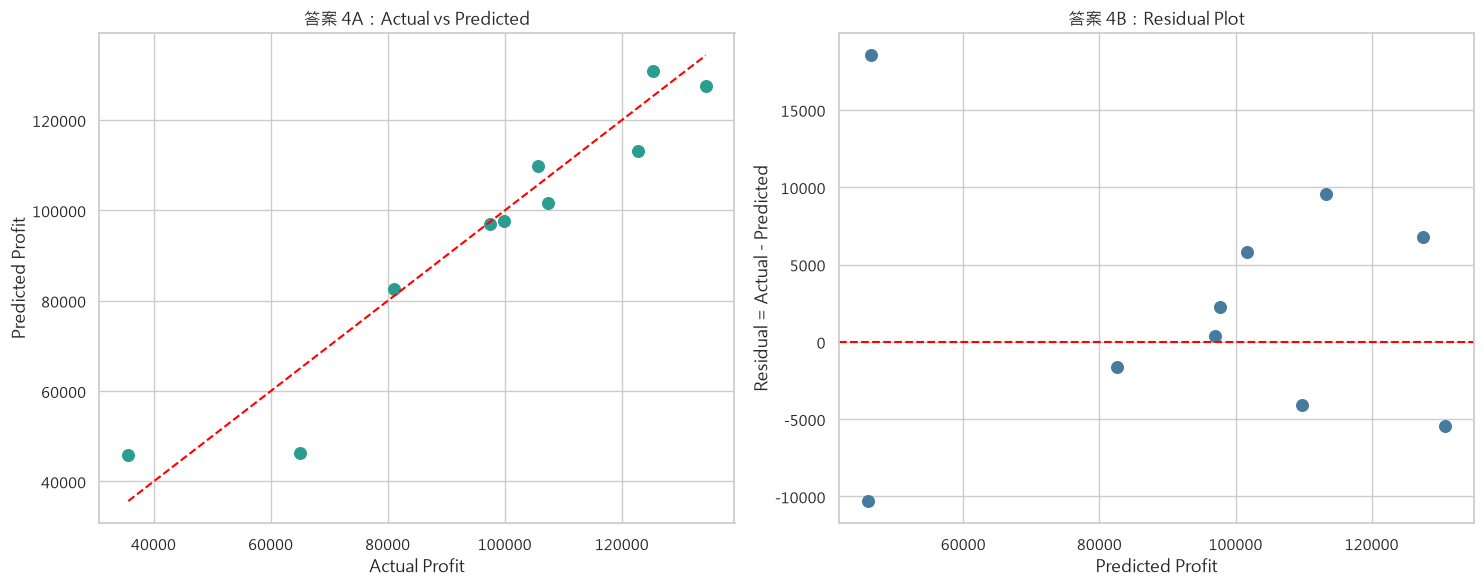

答案 4：Actual vs Predicted 點越接近紅色對角線越準確；Residual 若在 0 上下隨機分散較理想。
若殘差呈曲線、漏斗形或有極端點，可能表示非線性、異質變異或離群值問題。


In [36]:
# 補充題 4：最佳模型的 Actual vs Predicted 與 Residual Plot
best_test_prediction = final_test_prediction
best_test_residual = y_test.to_numpy() - best_test_prediction

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(y_test, best_test_prediction, color="#2a9d8f", s=70)
line_min = min(y_test.min(), best_test_prediction.min())
line_max = max(y_test.max(), best_test_prediction.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "--", color="red")
axes[0].set_title("答案 4A：Actual vs Predicted")
axes[0].set_xlabel("Actual Profit")
axes[0].set_ylabel("Predicted Profit")

axes[1].scatter(best_test_prediction, best_test_residual, color="#457b9d", s=70)
axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("答案 4B：Residual Plot")
axes[1].set_xlabel("Predicted Profit")
axes[1].set_ylabel("Residual = Actual - Predicted")
plt.tight_layout()
plt.show()

print("答案 4：Actual vs Predicted 點越接近紅色對角線越準確；Residual 若在 0 上下隨機分散較理想。")
print("若殘差呈曲線、漏斗形或有極端點，可能表示非線性、異質變異或離群值問題。")

## 答案 5：新增「產業別、公司年齡、員工數」可能如何改善模型？

- **產業別：** 不同產業的成本結構、成長速度與利潤率不同。加入產業別可讓模型區分例如軟體、製造與零售公司；通常需使用 One-Hot Encoding，也應確認每個產業有足夠樣本。
- **公司年齡：** 可反映公司所處生命週期。新創初期可能投入高但尚未獲利，成熟公司則可能有較穩定收入；其效果也可能是非線性的。
- **員工數：** 可作為營運規模代理變數，協助模型區分相同支出但規模不同的公司。不過員工數可能與 Administration 等支出高度相關，需要檢查共線性。

這些新特徵只有在資料品質良好、預測時能取得，而且通過 Training Set 內交叉驗證時，才算真正改善模型。加入更多欄位不必然提高泛化能力，也不能把預測關係直接解讀為因果效果。

## 五題重點答案整理

1. `random_state` 可能改變最佳模型與分數，小樣本對切分特別敏感。
2. Correlation 門檻從 `0.5` 降到 `0.3` 是否改變結果，取決於是否新增了特徵；門檻較低不代表一定較好。
3. SelectKBest 的 `k` 應綜合 Training Set 內 CV、波動與簡潔性選擇，不能只取 CV 最低者，更不能挑 Test RMSE 最低的 `k`。
4. Actual vs Predicted 用來看預測是否接近真值；Residual Plot 用來檢查系統性偏差、非線性與異質變異。
5. 新增產業別、公司年齡、員工數可能補充規模與生命週期資訊，但需要更多樣本、正確編碼與 CV 驗證。